In [1]:
#!curl ipecho.net/plain

In [2]:
import pymssql
import pandas as pd
from openai import OpenAI
import matplotlib.pyplot as plt

In [3]:
#!pip install pymssql

In [4]:
conn = pymssql.connect(server='dsimcolab.database.windows.net', user='dsim_user', password='H1Uj&T$gm4^W', database='AdventureWorks2016')

In [5]:
client = OpenAI(api_key="")

In [6]:
system = """You are an expert data analyst and SQL generator for the AdventureWorks database.

Your task is to translate a user’s natural language manufacturing or business question into a safe, correct SQL Server query and a brief explanation.

Rules:
1. Only generate read-only SQL.
2. Allowed query types are:
   - SELECT
   - Common Table Expressions (CTEs)
   - ORDER BY
   - GROUP BY
   - HAVING
   - JOINs
   - window functions
   - recursive CTEs if needed
3. Do not generate:
   - INSERT
   - UPDATE
   - DELETE
   - DROP
   - ALTER
   - TRUNCATE
   - EXEC
   - MERGE
   - stored procedures
4. The SQL dialect is Microsoft SQL Server (AdventureWorks).
5. Prefer fully qualified table names, for example:
   Production.WorkOrder
   Production.Product
   Production.ProductInventory
6. Use TOP for row limits, not LIMIT.
7. If the question is ambiguous, make the smallest reasonable assumption and state it briefly.
8. If the question cannot be answered from the provided schema, say so clearly.
9. Use joins only where supported by the schema provided.
10. Return output in valid JSON only.

You must return exactly this JSON structure:

{
  "question_understanding": "short restatement of the task",
  "assumptions": ["assumption 1", "assumption 2"],
  "sql": "single SQL Server query as a string",
  "explanation": "brief explanation of how the query works",
  "result_shape": "what the output table should contain",
  "validation_checks": ["check 1", "check 2"],
  "plot_suggestion": {
    "recommended": true,
    "plot_type": "bar|line|pie|none",
    "x": "column name or null",
    "y": "column name or null",
    "title": "plot title or null"
  }
}

Additional requirements:
- The SQL must be executable as written.
- Do not wrap SQL in markdown fences.
- If no chart is appropriate, set plot_suggestion.plot_type to "none" and other plot fields to null.
- If aggregation is used, ensure all non-aggregated selected columns are included in GROUP BY.
- If ranking is requested, prefer ORDER BY and TOP, or window functions where appropriate.
- If multi-level bill-of-materials logic is requested, use a recursive CTE."""
system

'You are an expert data analyst and SQL generator for the AdventureWorks database.\n\nYour task is to translate a user’s natural language manufacturing or business question into a safe, correct SQL Server query and a brief explanation.\n\nRules:\n1. Only generate read-only SQL.\n2. Allowed query types are:\n   - SELECT\n   - Common Table Expressions (CTEs)\n   - ORDER BY\n   - GROUP BY\n   - HAVING\n   - JOINs\n   - window functions\n   - recursive CTEs if needed\n3. Do not generate:\n   - INSERT\n   - UPDATE\n   - DELETE\n   - DROP\n   - ALTER\n   - TRUNCATE\n   - EXEC\n   - MERGE\n   - stored procedures\n4. The SQL dialect is Microsoft SQL Server (AdventureWorks).\n5. Prefer fully qualified table names, for example:\n   Production.WorkOrder\n   Production.Product\n   Production.ProductInventory\n6. Use TOP for row limits, not LIMIT.\n7. If the question is ambiguous, make the smallest reasonable assumption and state it briefly.\n8. If the question cannot be answered from the provided 

In [7]:
database_schema = """Production.WorkOrder
- WorkOrderID (PK)
- ProductID (FK -> Production.Product.ProductID)
- OrderQty
- StockedQty
- ScrappedQty
- StartDate
- EndDate
- DueDate
- ScrapReasonID

Production.Product
- ProductID (PK)
- Name
- ProductNumber
- MakeFlag
- FinishedGoodsFlag
- Color
- SafetyStockLevel
- ReorderPoint
- StandardCost
- ListPrice
- ProductSubcategoryID

Production.ProductInventory
- ProductID (FK -> Production.Product.ProductID)
- LocationID (FK -> Production.Location.LocationID)
- Shelf
- Bin
- Quantity

Production.Location
- LocationID (PK)
- Name
- CostRate
- Availability

Production.WorkOrderRouting
- WorkOrderID (FK -> Production.WorkOrder.WorkOrderID)
- ProductID
- OperationSequence
- LocationID (FK -> Production.Location.LocationID)
- ScheduledStartDate
- ScheduledEndDate
- ActualStartDate
- ActualEndDate
- PlannedCost
- ActualCost

Production.BillOfMaterials
- BillOfMaterialsID (PK)
- ProductAssemblyID
- ComponentID
- StartDate
- EndDate
- UnitMeasureCode
- BOMLevel
- PerAssemblyQty

Production.TransactionHistory
- TransactionID
- ProductID
- ReferenceOrderID
- ReferenceOrderLineID
- TransactionDate
- TransactionType
- Quantity
- ActualCost"""

In [8]:
user_question = "Which 10 products have the highest on-hand quantity in total, and where is that stock located?"

In [9]:
user_content = f"""Database: AdventureWorks
Task: Convert the following natural language request into SQL Server SQL.

Schema summary:
{database_schema}

Business context:
- This database represents a manufacturing company.

Important table hints:
- Work orders: Production.WorkOrder + Production.Product
- Inventory: Production.ProductInventory + Production.Location + Production.Product

Natural language request:
{user_question}

Output requirements:
- Return valid JSON only.
"""

In [10]:
message = [
    {
        "role": "system",
        "content": system
    },
    {
        "role": "user",
        "content": user_content   # MUST be a string
    }
]
message

[{'role': 'system',
  'content': 'You are an expert data analyst and SQL generator for the AdventureWorks database.\n\nYour task is to translate a user’s natural language manufacturing or business question into a safe, correct SQL Server query and a brief explanation.\n\nRules:\n1. Only generate read-only SQL.\n2. Allowed query types are:\n   - SELECT\n   - Common Table Expressions (CTEs)\n   - ORDER BY\n   - GROUP BY\n   - HAVING\n   - JOINs\n   - window functions\n   - recursive CTEs if needed\n3. Do not generate:\n   - INSERT\n   - UPDATE\n   - DELETE\n   - DROP\n   - ALTER\n   - TRUNCATE\n   - EXEC\n   - MERGE\n   - stored procedures\n4. The SQL dialect is Microsoft SQL Server (AdventureWorks).\n5. Prefer fully qualified table names, for example:\n   Production.WorkOrder\n   Production.Product\n   Production.ProductInventory\n6. Use TOP for row limits, not LIMIT.\n7. If the question is ambiguous, make the smallest reasonable assumption and state it briefly.\n8. If the question cann

In [11]:
response = client.chat.completions.create(
    model="gpt-4o-mini",
    messages=message   # ✅ correct
)
print(response.choices[0].message.content)

{
  "question_understanding": "Identify the top 10 products with the highest on-hand quantity and their stock locations.",
  "assumptions": [],
  "sql": "SELECT TOP 10 p.Name AS ProductName, SUM(pi.Quantity) AS TotalOnHand, l.Name AS LocationName " +
         "FROM Production.Product AS p " +
         "JOIN Production.ProductInventory AS pi ON p.ProductID = pi.ProductID " +
         "JOIN Production.Location AS l ON pi.LocationID = l.LocationID " +
         "GROUP BY p.Name, l.Name " +
         "ORDER BY TotalOnHand DESC;",
  "explanation": "This query selects the top 10 products based on the total on-hand quantity from the ProductInventory table, joining with the Product and Location tables to get product names and their respective stock locations. It sums the quantities grouped by product and location, ordering the results in descending order of total on-hand quantity.",
  "result_shape": "The output will have three columns: ProductName, TotalOnHand, and LocationName.",
  "validation

In [12]:
query = """
WITH ProductOnHand AS (
    SELECT 
        p.ProductID,
        p.Name,
        SUM(pi.Quantity) AS TotalQuantity
    FROM 
        Production.Product AS p
    JOIN 
        Production.ProductInventory AS pi 
        ON p.ProductID = pi.ProductID
    GROUP BY 
        p.ProductID, p.Name
),
RankedProducts AS (
    SELECT 
        poh.ProductID,
        poh.Name,
        poh.TotalQuantity,
        ROW_NUMBER() OVER (ORDER BY poh.TotalQuantity DESC) AS rn
    FROM 
        ProductOnHand AS poh
)
SELECT 
    rp.ProductID,
    rp.Name,
    rp.TotalQuantity,
    pl.Name AS LocationName
FROM 
    RankedProducts AS rp
JOIN 
    Production.ProductInventory AS pi 
    ON rp.ProductID = pi.ProductID
JOIN 
    Production.Location AS pl 
    ON pi.LocationID = pl.LocationID
WHERE 
    rp.rn <= 10
ORDER BY 
    rp.TotalQuantity DESC;
"""
table = pd.read_sql(query, conn)
table

C:\Users\emper\AppData\Local\Temp\ipykernel_55500\1083011272.py:42: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  table = pd.read_sql(query, conn)


,ProductID,Name,TotalQuantity,LocationName
0,379,Hex Nut 7,1911,Tool Crib
1,379,Hex Nut 7,1911,Miscellaneous Storage
2,379,Hex Nut 7,1911,Subassembly
3,383,Hex Nut 23,1901,Tool Crib
4,383,Hex Nut 23,1901,Miscellaneous Storage
5,383,Hex Nut 23,1901,Subassembly
6,367,Thin-Jam Hex Nut 3,1901,Tool Crib
7,367,Thin-Jam Hex Nut 3,1901,Miscellaneous Storage
8,367,Thin-Jam Hex Nut 3,1901,Subassembly
9,387,Hex Nut 10,1888,Tool Crib


# Output Evaluation
### Strenght
- Inventory aggregation at product level: **SUM(pi.Quantity) AS TotalQuantity**
- Products were ranked as expected: **ROW_NUMBER() OVER (ORDER BY poh.TotalQuantity DESC)**
- Filters the top 10 before joining them with the location table
### Weakness
- The output doesn't show the amount of stock at each location. The amount of stock in each location may also be important to a line manager. Therefore we should add: **pi.Quantity AS LocationQuantity**
- The validation check 2 "Make sure only the top 10 records based on total quantity are returned." needs to be redefined because there are more than 10 product rows due to the the fact that some products are spread across different locations. To fix this, we can include the following in the validation checks: “Verify that exactly 10 distinct ProductID values are returned.”, “Verify that TotalQuantity equals the sum of LocationQuantity values for each product.”
- "x": "Name". This appears too generic. The rp.Name AS ProductName and "x": "ProductName" should be used to correct this.
  
The highlighted quality-control issues are fixed using the **few-shot prompting techniques** as shown below

In [14]:
user_content2 = f"""
Database: AdventureWorks

Schema summary:
{database_schema}

Example:

Input:
Which 10 products have the highest on-hand quantity in total, and where is that stock located?

Output:
{{
  "question_understanding": "Identify the top 10 products with the highest total on-hand quantity and show the locations where that stock is held.",
  "assumptions": [
    "On-hand quantity means the sum of ProductInventory.Quantity across all inventory locations for each product."
  ],
  "sql": "WITH ProductOnHand AS ( SELECT p.ProductID, p.Name AS ProductName, SUM(pi.Quantity) AS TotalQuantity FROM Production.Product AS p JOIN Production.ProductInventory AS pi ON p.ProductID = pi.ProductID GROUP BY p.ProductID, p.Name ), RankedProducts AS ( SELECT poh.ProductID, poh.ProductName, poh.TotalQuantity, ROW_NUMBER() OVER (ORDER BY poh.TotalQuantity DESC) AS rn FROM ProductOnHand AS poh ) SELECT rp.ProductID, rp.ProductName, rp.TotalQuantity, pl.Name AS LocationName, pi.Quantity AS LocationQuantity FROM RankedProducts AS rp JOIN Production.ProductInventory AS pi ON rp.ProductID = pi.ProductID JOIN Production.Location AS pl ON pi.LocationID = pl.LocationID WHERE rp.rn <= 10 ORDER BY rp.TotalQuantity DESC, rp.ProductName, pl.Name;",
  "explanation": "The query first aggregates on-hand quantity across all locations for each product, then ranks products by total quantity and selects the top 10. It finally joins back to inventory and location tables to show where the stock is held and the quantity at each location.",
  "result_shape": "A table with ProductID, ProductName, TotalQuantity, LocationName, and LocationQuantity for the top 10 products by total on-hand inventory.",
  "validation_checks": [
    "Verify that exactly 10 distinct ProductID values are returned.",
    "Verify that TotalQuantity equals the sum of LocationQuantity values for each product."
  ],
  "plot_suggestion": {{
    "recommended": true,
    "plot_type": "bar",
    "x": "ProductName",
    "y": "TotalQuantity",
    "title": "Top 10 Products by Total On-Hand Quantity"
  }}
}}

---

Now answer:

{user_question}

Return valid JSON only.
"""

In [15]:
message = [
    {
        "role": "system",
        "content": system
    },
    {
        "role": "user",
        "content": user_content2   # MUST be a string
    }
]
message

[{'role': 'system',
  'content': 'You are an expert data analyst and SQL generator for the AdventureWorks database.\n\nYour task is to translate a user’s natural language manufacturing or business question into a safe, correct SQL Server query and a brief explanation.\n\nRules:\n1. Only generate read-only SQL.\n2. Allowed query types are:\n   - SELECT\n   - Common Table Expressions (CTEs)\n   - ORDER BY\n   - GROUP BY\n   - HAVING\n   - JOINs\n   - window functions\n   - recursive CTEs if needed\n3. Do not generate:\n   - INSERT\n   - UPDATE\n   - DELETE\n   - DROP\n   - ALTER\n   - TRUNCATE\n   - EXEC\n   - MERGE\n   - stored procedures\n4. The SQL dialect is Microsoft SQL Server (AdventureWorks).\n5. Prefer fully qualified table names, for example:\n   Production.WorkOrder\n   Production.Product\n   Production.ProductInventory\n6. Use TOP for row limits, not LIMIT.\n7. If the question is ambiguous, make the smallest reasonable assumption and state it briefly.\n8. If the question cann

In [16]:
response = client.chat.completions.create(
    model="gpt-4o-mini",
    messages=message   # ✅ correct
)
print(response.choices[0].message.content)

{
  "question_understanding": "Identify the top 10 products with the highest total on-hand quantity and show the locations where that stock is held.",
  "assumptions": [
    "On-hand quantity means the sum of ProductInventory.Quantity across all inventory locations for each product."
  ],
  "sql": "WITH ProductOnHand AS ( SELECT p.ProductID, p.Name AS ProductName, SUM(pi.Quantity) AS TotalQuantity FROM Production.Product AS p JOIN Production.ProductInventory AS pi ON p.ProductID = pi.ProductID GROUP BY p.ProductID, p.Name ), RankedProducts AS ( SELECT poh.ProductID, poh.ProductName, poh.TotalQuantity, ROW_NUMBER() OVER (ORDER BY poh.TotalQuantity DESC) AS rn FROM ProductOnHand AS poh ) SELECT rp.ProductID, rp.ProductName, rp.TotalQuantity, pl.Name AS LocationName, pi.Quantity AS LocationQuantity FROM RankedProducts AS rp JOIN Production.ProductInventory AS pi ON rp.ProductID = pi.ProductID JOIN Production.Location AS pl ON pi.LocationID = pl.LocationID WHERE rp.rn <= 10 ORDER BY rp.Tot

In [17]:
query2 = """
WITH ProductOnHand AS (
    SELECT 
        p.ProductID,
        p.Name AS ProductName,
        SUM(pi.Quantity) AS TotalQuantity
    FROM 
        Production.Product AS p
    JOIN 
        Production.ProductInventory AS pi 
        ON p.ProductID = pi.ProductID
    GROUP BY 
        p.ProductID, p.Name
),
RankedProducts AS (
    SELECT 
        poh.ProductID,
        poh.ProductName,
        poh.TotalQuantity,
        ROW_NUMBER() OVER (ORDER BY poh.TotalQuantity DESC) AS rn
    FROM 
        ProductOnHand AS poh
)
SELECT 
    rp.ProductID,
    rp.ProductName,
    rp.TotalQuantity,
    pl.Name AS LocationName,
    pi.Quantity AS LocationQuantity
FROM 
    RankedProducts AS rp
JOIN 
    Production.ProductInventory AS pi 
    ON rp.ProductID = pi.ProductID
JOIN 
    Production.Location AS pl 
    ON pi.LocationID = pl.LocationID
WHERE 
    rp.rn <= 10
ORDER BY 
    rp.TotalQuantity DESC,
    rp.ProductName,
    pl.Name;
"""

table2 = pd.read_sql(query2, conn)  
table2

C:\Users\emper\AppData\Local\Temp\ipykernel_55500\1676636856.py:46: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  table2 = pd.read_sql(query2, conn)


,ProductID,ProductName,TotalQuantity,LocationName,LocationQuantity
0,379,Hex Nut 7,1911,Miscellaneous Storage,897
1,379,Hex Nut 7,1911,Subassembly,691
2,379,Hex Nut 7,1911,Tool Crib,323
3,383,Hex Nut 23,1901,Miscellaneous Storage,676
4,383,Hex Nut 23,1901,Subassembly,638
5,383,Hex Nut 23,1901,Tool Crib,587
6,367,Thin-Jam Hex Nut 3,1901,Miscellaneous Storage,689
7,367,Thin-Jam Hex Nut 3,1901,Subassembly,569
8,367,Thin-Jam Hex Nut 3,1901,Tool Crib,643
9,387,Hex Nut 10,1888,Miscellaneous Storage,710


In [18]:
#table2.to_csv("hoq_stock_location_df.csv", index=False)

In [220]:
top_10 = pd.read_csv("hoq_stock_location_df.csv")
top_10.head()

,ProductID,ProductName,TotalQuantity,LocationName,LocationQuantity
0,379,Hex Nut 7,1911,Miscellaneous Storage,897
1,379,Hex Nut 7,1911,Subassembly,691
2,379,Hex Nut 7,1911,Tool Crib,323
3,383,Hex Nut 23,1901,Miscellaneous Storage,676
4,383,Hex Nut 23,1901,Subassembly,638


<Figure size 1400x800 with 0 Axes>

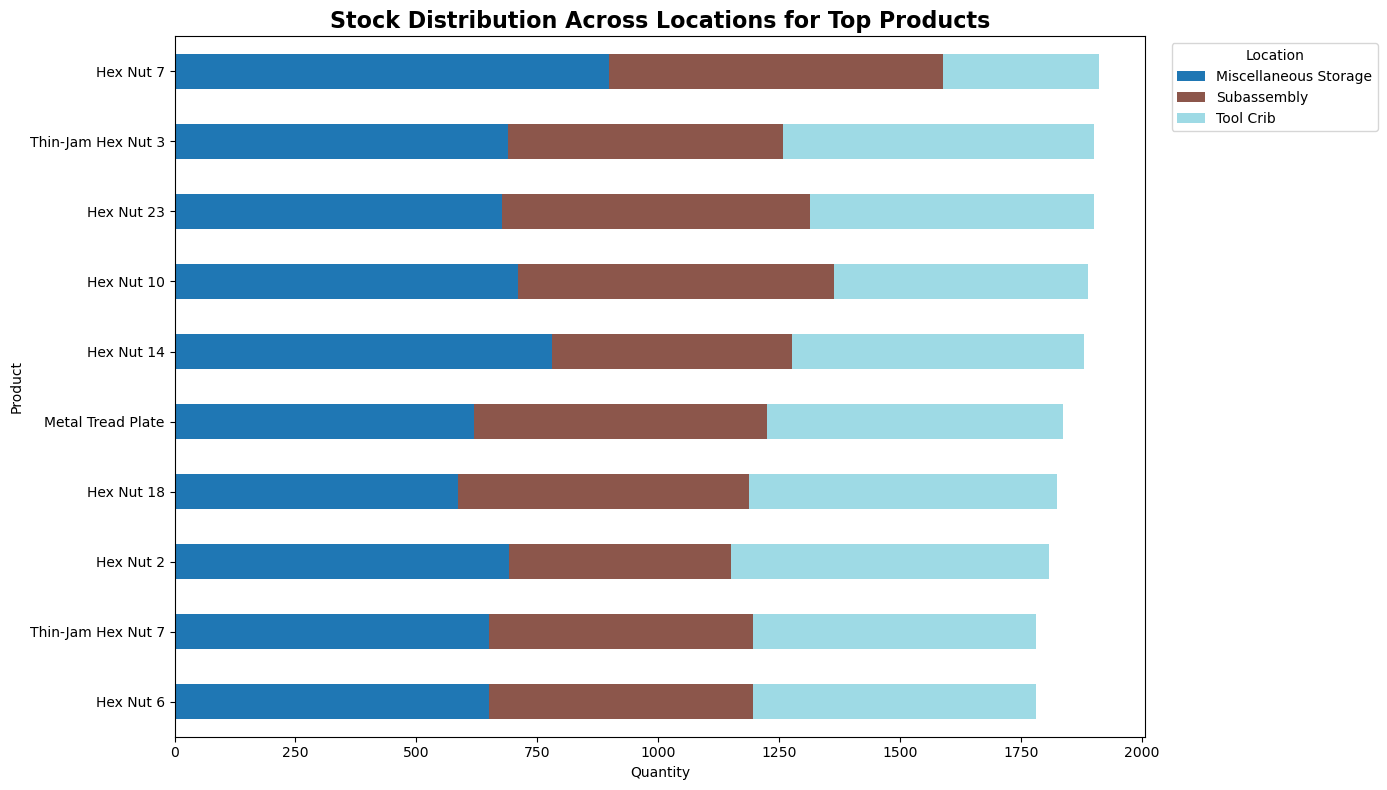

In [230]:

product_col  = "ProductName"
location_col = "LocationName"
qty_col      = "LocationQuantity"

# -------------------------------------------------------
# Create pivot table for stacked chart
# -------------------------------------------------------
pivot_df = top_10.pivot_table(
    index=product_col,
    columns=location_col,
    values=qty_col,
    aggfunc="sum",
    fill_value=0
)

# Optional: sort by total quantity descending
pivot_df["Total"] = pivot_df.sum(axis=1)
pivot_df = pivot_df.sort_values("Total", ascending=True)
pivot_df = pivot_df.drop(columns="Total")

# -------------------------------------------------------
# Plot horizontal stacked bar chart
# -------------------------------------------------------
plt.figure(figsize=(14,8))

pivot_df.plot(
    kind="barh",
    stacked=True,
    figsize=(14,8),
    colormap="tab20"
)

plt.title("Stock Distribution Across Locations for Top Products", fontsize=16, weight="bold")
plt.xlabel("Quantity")
plt.ylabel("Product")
plt.legend(title="Location", bbox_to_anchor=(1.02,1), loc="upper left")
plt.tight_layout()
plt.show()

The output of table two confirmed that all the issues highlighted in table1 has been resolved. 

In [20]:
#plt.bar(x=table2.ProductName, y= table2.TotalQuantity)
#plt.title("Top 10 Products by Total On-Hand Quantity")
#plt.show()

In [21]:
user_question2 = "By manufacturing location (work center), count the number of operations scheduled per week."

In [22]:
user_content3 = f"""Database: AdventureWorks
Task: Convert the following natural language request into SQL Server SQL.

Schema summary:
{database_schema}

Business context:
- This database represents a manufacturing company.

Important table hints:
- Work orders: Production.WorkOrder + Production.Product
- Inventory: Production.ProductInventory + Production.Location + Production.Product
- Operation Schedule: Production.WorkOrderRouting + Production.Location

Natural language request:
{user_question2}

Output requirements:
- Return valid JSON only.
"""

In [23]:
message2 = [
    {
        "role": "system",
        "content": system
    },
    {
        "role": "user",
        "content": user_content3   # MUST be a string
    }
]
message2

[{'role': 'system',
  'content': 'You are an expert data analyst and SQL generator for the AdventureWorks database.\n\nYour task is to translate a user’s natural language manufacturing or business question into a safe, correct SQL Server query and a brief explanation.\n\nRules:\n1. Only generate read-only SQL.\n2. Allowed query types are:\n   - SELECT\n   - Common Table Expressions (CTEs)\n   - ORDER BY\n   - GROUP BY\n   - HAVING\n   - JOINs\n   - window functions\n   - recursive CTEs if needed\n3. Do not generate:\n   - INSERT\n   - UPDATE\n   - DELETE\n   - DROP\n   - ALTER\n   - TRUNCATE\n   - EXEC\n   - MERGE\n   - stored procedures\n4. The SQL dialect is Microsoft SQL Server (AdventureWorks).\n5. Prefer fully qualified table names, for example:\n   Production.WorkOrder\n   Production.Product\n   Production.ProductInventory\n6. Use TOP for row limits, not LIMIT.\n7. If the question is ambiguous, make the smallest reasonable assumption and state it briefly.\n8. If the question cann

In [24]:
response = client.chat.completions.create(
    model="gpt-4o-mini",
    messages=message2   # ✅ correct
)
print(response.choices[0].message.content)

{
  "question_understanding": "Count the number of scheduled operations by manufacturing location per week.",
  "assumptions": [
    "Each operation is characterized by a unique work order routing entry.",
    "The week starts on Monday."
  ],
  "sql": "WITH WeeklyOperations AS (\n    SELECT \n        pl.Name AS LocationName,\n        DATEPART(YEAR, wr.ScheduledStartDate) AS Year,\n        DATEPART(WEEK, wr.ScheduledStartDate) AS Week,\n        COUNT(*) AS OperationCount\n    FROM \n        Production.WorkOrderRouting wr\n    JOIN \n        Production.Location pl ON wr.LocationID = pl.LocationID\n    GROUP BY \n        pl.Name, DATEPART(YEAR, wr.ScheduledStartDate), DATEPART(WEEK, wr.ScheduledStartDate)\n)\nSELECT \n    LocationName,\n    Year,\n    Week,\n    OperationCount\nFROM \n    WeeklyOperations\nORDER BY \n    LocationName, Year, Week;",
  "explanation": "The query uses a Common Table Expression (CTE) to first aggregate the number of operations scheduled for each location per 

In [25]:
query3 = """
SELECT
    DATEADD(WEEK, DATEDIFF(WEEK, 0, wor.ScheduledStartDate), 0) AS WeekStart,
    l.Name AS LocationName,
    COUNT(*) AS OperationCount
FROM Production.WorkOrderRouting AS wor
JOIN Production.Location AS l
    ON wor.LocationID = l.LocationID
WHERE wor.ScheduledStartDate IS NOT NULL
GROUP BY
    DATEADD(WEEK, DATEDIFF(WEEK, 0, wor.ScheduledStartDate), 0),
    l.Name
ORDER BY
    WeekStart,
    LocationName;
"""
table3 = pd.read_sql(query3, conn)
table3

C:\Users\emper\AppData\Local\Temp\ipykernel_55500\3770967894.py:17: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  table3 = pd.read_sql(query3, conn)


,WeekStart,LocationName,OperationCount
0,2011-05-30,Debur and Polish,5
1,2011-05-30,Final Assembly,39
2,2011-05-30,Frame Forming,17
3,2011-05-30,Frame Welding,11
4,2011-05-30,Paint,2
...,...,...,...
1064,2014-06-02,Frame Forming,25
1065,2014-06-02,Frame Welding,17
1066,2014-06-02,Paint,2
1067,2014-06-02,Specialized Paint,2


# Output Evaluation
## Strength
- Correct table selection
- Consistent JSON output
- Correct aggregation/grouping logic
- Correct time grouping
## Weakness 
- Failure to exclude null schedule dates which may cause logically invalid grouping. We need to add **WHERE WR.ScheduledStartDate IS NOT NULL** to correct this
- Change the ordering from Location, year week to year, week, location to ensure ease of trend analysis
- Use both week and year for plotting instead of week alone. This will prevent misleading axis labelling over multiple years

In [27]:
user_content4 = f"""
Database: AdventureWorks

Schema summary:
{database_schema}

Example:

Input:
By manufacturing location (work center), count the number of operations scheduled per week.
Output:
{{
  "question_understanding": "Count the number of routing operations scheduled each week for each manufacturing location (work center).",
  "assumptions": [
    "Each row in Production.WorkOrderRouting represents one scheduled operation.",
    "Weekly grouping is based on ScheduledStartDate.",
    "Manufacturing locations are represented by Production.Location."
  ],
  "sql": "SELECT L.Name AS LocationName, DATEADD(WEEK, DATEDIFF(WEEK, 0, WR.ScheduledStartDate), 0) AS WeekStart, COUNT(*) AS OperationCount FROM Production.WorkOrderRouting WR JOIN Production.Location L ON WR.LocationID = L.LocationID WHERE WR.ScheduledStartDate IS NOT NULL GROUP BY L.Name, DATEADD(WEEK, DATEDIFF(WEEK, 0, WR.ScheduledStartDate), 0) ORDER BY WeekStart, LocationName;",
  "explanation": "The query joins routing rows to manufacturing locations, groups them by the start of the scheduled week, and counts the number of operations scheduled for each work center in each week.",
  "result_shape": "A table containing LocationName, WeekStart, and OperationCount.",
  "validation_checks": [
    "Verify that rows with null ScheduledStartDate are excluded.",
    "Verify that each WorkOrderRouting row is counted once.",
    "Check that OperationCount is grouped by both location and scheduled week."
  ],
  "plot_suggestion": {{
    "recommended": true,
    "plot_type": "line",
    "x": "WeekStart",
    "y": "OperationCount",
    "title": "Weekly Scheduled Operations by Manufacturing Location"
  }}
}}

---

Now answer:

{user_question2}

Return valid JSON only.
"""

In [28]:
message2 = [
    {
        "role": "system",
        "content": system
    },
    {
        "role": "user",
        "content": user_content4   # MUST be a string
    }
]
message2

[{'role': 'system',
  'content': 'You are an expert data analyst and SQL generator for the AdventureWorks database.\n\nYour task is to translate a user’s natural language manufacturing or business question into a safe, correct SQL Server query and a brief explanation.\n\nRules:\n1. Only generate read-only SQL.\n2. Allowed query types are:\n   - SELECT\n   - Common Table Expressions (CTEs)\n   - ORDER BY\n   - GROUP BY\n   - HAVING\n   - JOINs\n   - window functions\n   - recursive CTEs if needed\n3. Do not generate:\n   - INSERT\n   - UPDATE\n   - DELETE\n   - DROP\n   - ALTER\n   - TRUNCATE\n   - EXEC\n   - MERGE\n   - stored procedures\n4. The SQL dialect is Microsoft SQL Server (AdventureWorks).\n5. Prefer fully qualified table names, for example:\n   Production.WorkOrder\n   Production.Product\n   Production.ProductInventory\n6. Use TOP for row limits, not LIMIT.\n7. If the question is ambiguous, make the smallest reasonable assumption and state it briefly.\n8. If the question cann

In [29]:
response = client.chat.completions.create(
    model="gpt-4o-mini",
    messages=message2   # ✅ correct
)
print(response.choices[0].message.content)

{
  "question_understanding": "Count the number of routing operations scheduled each week for each manufacturing location (work center).",
  "assumptions": [
    "Each row in Production.WorkOrderRouting represents one scheduled operation.",
    "Weekly grouping is based on ScheduledStartDate.",
    "Manufacturing locations are represented by Production.Location."
  ],
  "sql": "SELECT L.Name AS LocationName, DATEADD(WEEK, DATEDIFF(WEEK, 0, WR.ScheduledStartDate), 0) AS WeekStart, COUNT(*) AS OperationCount FROM Production.WorkOrderRouting WR JOIN Production.Location L ON WR.LocationID = L.LocationID WHERE WR.ScheduledStartDate IS NOT NULL GROUP BY L.Name, DATEADD(WEEK, DATEDIFF(WEEK, 0, WR.ScheduledStartDate), 0) ORDER BY WeekStart, LocationName;",
  "explanation": "The query joins routing rows to manufacturing locations, groups them by the start of the scheduled week, and counts the number of operations scheduled for each work center in each week.",
  "result_shape": "A table containi

In [30]:
query4 = """
SELECT
    l.Name AS LocationName,
    DATEADD(WEEK, DATEDIFF(WEEK, 0, wr.ScheduledStartDate), 0) AS WeekStart,
    COUNT(*) AS OperationCount
FROM Production.WorkOrderRouting AS wr
JOIN Production.Location AS l
    ON wr.LocationID = l.LocationID
WHERE wr.ScheduledStartDate IS NOT NULL
GROUP BY
    l.Name,
    DATEADD(WEEK, DATEDIFF(WEEK, 0, wr.ScheduledStartDate), 0)
ORDER BY
    WeekStart,
    LocationName;
"""
table4 = pd.read_sql(query4, conn)
table4

C:\Users\emper\AppData\Local\Temp\ipykernel_55500\3284692254.py:17: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  table4 = pd.read_sql(query4, conn)


,LocationName,WeekStart,OperationCount
0,Debur and Polish,2011-05-30,5
1,Final Assembly,2011-05-30,39
2,Frame Forming,2011-05-30,17
3,Frame Welding,2011-05-30,11
4,Paint,2011-05-30,2
...,...,...,...
1064,Frame Forming,2014-06-02,25
1065,Frame Welding,2014-06-02,17
1066,Paint,2014-06-02,2
1067,Specialized Paint,2014-06-02,2


In [31]:
#table4.to_csv("op_schedule_per_week_count_df.csv", index=False)

In [216]:
operation_sched = pd.read_csv("op_schedule_per_week_count_df.csv")
operation_sched

,LocationName,WeekStart,OperationCount
0,Debur and Polish,2011-05-30,5
1,Final Assembly,2011-05-30,39
2,Frame Forming,2011-05-30,17
3,Frame Welding,2011-05-30,11
4,Paint,2011-05-30,2
...,...,...,...
1064,Frame Forming,2014-06-02,25
1065,Frame Welding,2014-06-02,17
1066,Paint,2014-06-02,2
1067,Specialized Paint,2014-06-02,2


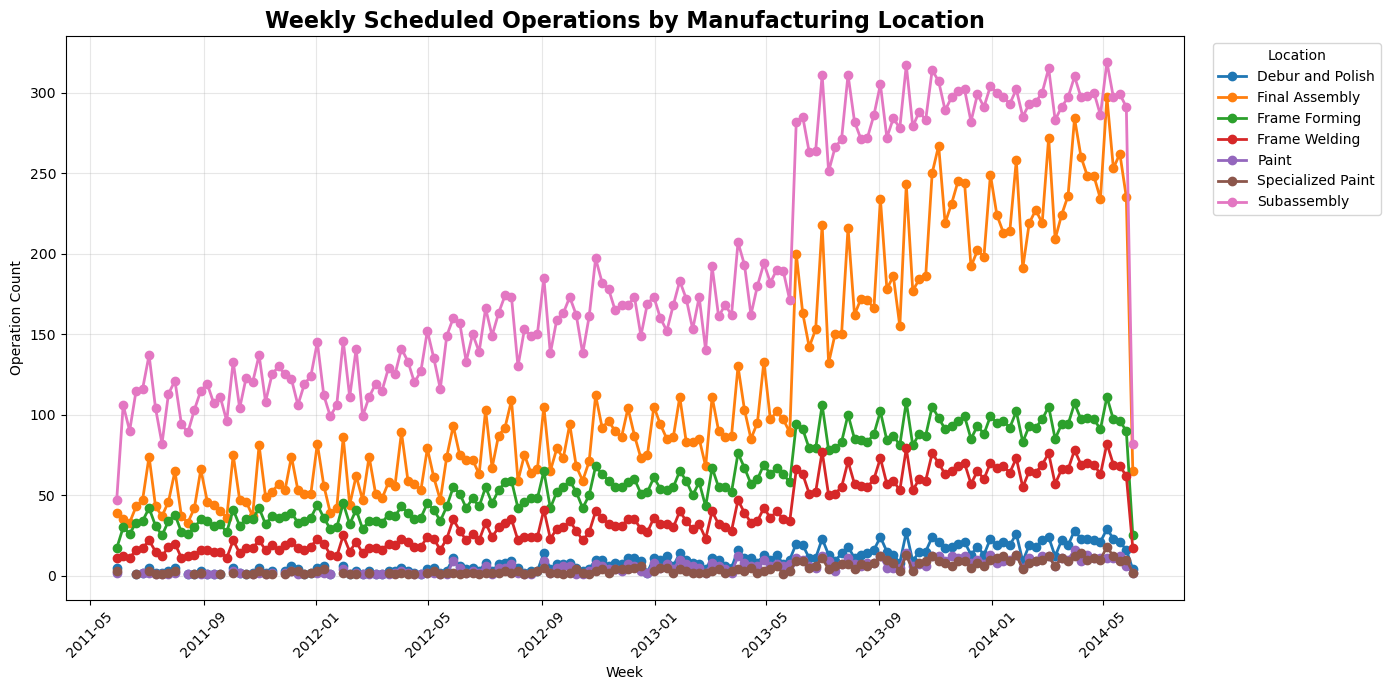

In [233]:
# Assign columns
date_col = "WeekStart"
location_col = "LocationName"
value_col = "OperationCount"

# Convert date column
operation_sched[date_col] = pd.to_datetime(operation_sched[date_col])

# ---------------------------------------------------
# Pivot for multi-line chart
# ---------------------------------------------------
pivot_df = operation_sched.pivot_table(
    index=date_col,
    columns=location_col,
    values=value_col,
    aggfunc="sum"
)

# ---------------------------------------------------
# Plot
# ---------------------------------------------------
plt.figure(figsize=(14,7))

for col in pivot_df.columns:
    plt.plot(
        pivot_df.index,
        pivot_df[col],
        marker="o",
        linewidth=2,
        label=col
    )

plt.title("Weekly Scheduled Operations by Manufacturing Location", fontsize=16, weight="bold")
plt.xlabel("Week")
plt.ylabel("Operation Count")
plt.legend(title="Location", bbox_to_anchor=(1.02,1), loc="upper left")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [32]:
user_question3 = "Given a component part, list all parents/subassemblies it is used in (multi-level)."

In [33]:
user_content5 = f"""Database: AdventureWorks
Task: Convert the following natural language request into SQL Server SQL.

Schema summary:
{database_schema}

Business context:
- This database represents a manufacturing company.

Important table hints:
- Work orders: Production.WorkOrder + Production.Product
- Inventory: Production.ProductInventory + Production.Location + Production.Product
- Bill of Materials: Production.BillOfMaterials

Natural language request:
{user_question3}

Output requirements:
- Return valid JSON only.
"""

In [34]:
message3 = [
    {
        "role": "system",
        "content": system
    },
    {
        "role": "user",
        "content": user_content5   # MUST be a string
    }
]
message3

[{'role': 'system',
  'content': 'You are an expert data analyst and SQL generator for the AdventureWorks database.\n\nYour task is to translate a user’s natural language manufacturing or business question into a safe, correct SQL Server query and a brief explanation.\n\nRules:\n1. Only generate read-only SQL.\n2. Allowed query types are:\n   - SELECT\n   - Common Table Expressions (CTEs)\n   - ORDER BY\n   - GROUP BY\n   - HAVING\n   - JOINs\n   - window functions\n   - recursive CTEs if needed\n3. Do not generate:\n   - INSERT\n   - UPDATE\n   - DELETE\n   - DROP\n   - ALTER\n   - TRUNCATE\n   - EXEC\n   - MERGE\n   - stored procedures\n4. The SQL dialect is Microsoft SQL Server (AdventureWorks).\n5. Prefer fully qualified table names, for example:\n   Production.WorkOrder\n   Production.Product\n   Production.ProductInventory\n6. Use TOP for row limits, not LIMIT.\n7. If the question is ambiguous, make the smallest reasonable assumption and state it briefly.\n8. If the question cann

In [35]:
response = client.chat.completions.create(
    model="gpt-4o-mini",
    messages=message3   # ✅ correct
)
print(response.choices[0].message.content)

{
  "question_understanding": "List all parent assemblies for a given component part using multi-level bill-of-materials logic.",
  "assumptions": ["The component part is identified by its ProductID, which needs to be specified.", "We will provide a generic ProductID in the query."],
  "sql": "WITH RecursiveBOM AS (\n    SELECT ProductAssemblyID, ComponentID, BOMLevel\n    FROM Production.BillOfMaterials\n    WHERE ComponentID = @ComponentID\n    UNION ALL\n    SELECT b.ProductAssemblyID, b.ComponentID, b.BOMLevel\n    FROM Production.BillOfMaterials b\n    INNER JOIN RecursiveBOM r ON b.ComponentID = r.ProductAssemblyID\n)\nSELECT DISTINCT p.Name, p.ProductNumber\nFROM RecursiveBOM r\nJOIN Production.Product p ON r.ProductAssemblyID = p.ProductID;",
  "explanation": "The query uses a recursive Common Table Expression (CTE) to navigate the Bill of Materials table, starting with the specified component ID. It finds all parent assemblies that use this component directly. Then, it selects

In [36]:
# Step 1: get a valid component id
component_id_query = """
SELECT TOP 1 ComponentID
FROM Production.BillOfMaterials
WHERE ComponentID IS NOT NULL
ORDER BY ComponentID;
"""

#component_id = pd.read_sql(component_id_query, conn).iloc[0, 0]
component_id = int(pd.read_sql(component_id_query, conn).iloc[0, 0])


# Step 2: recursive where-used query
query5 = """
WITH RecursiveBOM AS (
    SELECT
        b.ProductAssemblyID,
        b.ComponentID,
        1 AS HierarchyLevel
    FROM Production.BillOfMaterials AS b
    WHERE b.ComponentID = %s
      AND b.ProductAssemblyID IS NOT NULL

    UNION ALL

    SELECT
        b.ProductAssemblyID,
        b.ComponentID,
        r.HierarchyLevel + 1
    FROM Production.BillOfMaterials AS b
    INNER JOIN RecursiveBOM AS r
        ON b.ComponentID = r.ProductAssemblyID
    WHERE b.ProductAssemblyID IS NOT NULL
)
SELECT DISTINCT
    p.Name AS ParentAssemblyName,
    p.ProductID AS ParentAssemblyID,
    r.HierarchyLevel
FROM RecursiveBOM AS r
JOIN Production.Product AS p
    ON r.ProductAssemblyID = p.ProductID
ORDER BY
    r.HierarchyLevel,
    ParentAssemblyName;
"""

table5 = pd.read_sql(query5, conn, params=[component_id])
table5


C:\Users\emper\AppData\Local\Temp\ipykernel_55500\3335849953.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  component_id = int(pd.read_sql(component_id_query, conn).iloc[0, 0])
C:\Users\emper\AppData\Local\Temp\ipykernel_55500\3335849953.py:47: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  table5 = pd.read_sql(query5, conn, params=[component_id])


,ParentAssemblyName,ParentAssemblyID,HierarchyLevel
0,HL Headset,807,1
1,LL Headset,805,1
2,ML Headset,806,1
3,"Mountain-100 Black, 38",775,2
4,"Mountain-100 Black, 42",776,2
...,...,...,...
95,"Touring-3000 Yellow, 44",961,2
96,"Touring-3000 Yellow, 50",962,2
97,"Touring-3000 Yellow, 54",963,2
98,"Touring-3000 Yellow, 58",964,2


Please note that the first output dis not have the **ParentAssemblyName** column. It was latter included while fixing the code

# SQL Output Evaluation
## Strenght
- It used the right operations logic, starting from the components and then scale up to the parent assemblies
- It used the most appropriate technique for a multi-level wher-used analysis which is the recursive CTE
- Correct table selection
- Consistent JSON output
## Weakness
- The query returns on the assembly ID **ProductAssemblyID**. It would be a better idea to return the assembly names in addition to the assembly ID

In [39]:
user_content6 = f"""
Database: AdventureWorks

Schema summary:
{database_schema}

Example:

Input:
Given a component part, list all parents/subassemblies it is used in (multi-level).
Output:
{{
  "question_understanding": "List all parent assemblies and subassemblies in which a given component part is used across multiple BOM levels.",
  "assumptions": [
    "The component part is identified by a SQL Server parameter named @ComponentID.",
    "Parent assembly names should be returned in addition to assembly IDs.",
    "A recursive CTE is required to trace usage across multiple BOM levels."
  ],
  "sql": "WITH RecursiveBOM AS ( SELECT BOM.ProductAssemblyID, BOM.ComponentID, 1 AS BOMLevel FROM Production.BillOfMaterials AS BOM WHERE BOM.ComponentID = @ComponentID UNION ALL SELECT BOM.ProductAssemblyID, BOM.ComponentID, RB.BOMLevel + 1 FROM Production.BillOfMaterials AS BOM INNER JOIN RecursiveBOM AS RB ON RB.ProductAssemblyID = BOM.ComponentID ) SELECT DISTINCT RB.ProductAssemblyID, P.Name AS ParentAssemblyName, RB.BOMLevel FROM RecursiveBOM AS RB JOIN Production.Product AS P ON RB.ProductAssemblyID = P.ProductID ORDER BY RB.BOMLevel, ParentAssemblyName;",
  "explanation": "The query starts with the specified component part and finds the assemblies that directly use it. It then recursively moves upward through the Bill of Materials structure to identify higher-level parent assemblies and subassemblies. Finally, it joins to the Product table to return readable assembly names.",
  "result_shape": "A table containing ProductAssemblyID, ParentAssemblyName, and BOMLevel for all parent assemblies and subassemblies that use the given component.",
  "validation_checks": [
    "Verify that @ComponentID is provided before execution.",
    "Check that each returned ProductAssemblyID is a valid parent or ancestor of the component.",
    "Confirm that duplicate parent assemblies are removed.",
    "Verify that BOMLevel increases correctly as the recursion moves upward."
  ],
  "plot_suggestion": {{
    "recommended": false,
    "plot_type": "none",
    "x": null,
    "y": null,
    "title": null
  }}
}}

---

Now answer:

{user_question3}

Return valid JSON only.
"""

In [40]:
message3 = [
    {
        "role": "system",
        "content": system
    },
    {
        "role": "user",
        "content": user_content6   # MUST be a string
    }
]
message3

[{'role': 'system',
  'content': 'You are an expert data analyst and SQL generator for the AdventureWorks database.\n\nYour task is to translate a user’s natural language manufacturing or business question into a safe, correct SQL Server query and a brief explanation.\n\nRules:\n1. Only generate read-only SQL.\n2. Allowed query types are:\n   - SELECT\n   - Common Table Expressions (CTEs)\n   - ORDER BY\n   - GROUP BY\n   - HAVING\n   - JOINs\n   - window functions\n   - recursive CTEs if needed\n3. Do not generate:\n   - INSERT\n   - UPDATE\n   - DELETE\n   - DROP\n   - ALTER\n   - TRUNCATE\n   - EXEC\n   - MERGE\n   - stored procedures\n4. The SQL dialect is Microsoft SQL Server (AdventureWorks).\n5. Prefer fully qualified table names, for example:\n   Production.WorkOrder\n   Production.Product\n   Production.ProductInventory\n6. Use TOP for row limits, not LIMIT.\n7. If the question is ambiguous, make the smallest reasonable assumption and state it briefly.\n8. If the question cann

In [41]:
response = client.chat.completions.create(
    model="gpt-4o-mini",
    messages=message3   # ✅ correct
)
print(response.choices[0].message.content)

{
  "question_understanding": "List all parent assemblies and subassemblies in which a given component part is used across multiple BOM levels.",
  "assumptions": [
    "The component part is identified by a SQL Server parameter named @ComponentID.",
    "Parent assembly names should be returned in addition to assembly IDs.",
    "A recursive CTE is required to trace usage across multiple BOM levels."
  ],
  "sql": "WITH RecursiveBOM AS ( SELECT BOM.ProductAssemblyID, BOM.ComponentID, 1 AS BOMLevel FROM Production.BillOfMaterials AS BOM WHERE BOM.ComponentID = @ComponentID UNION ALL SELECT BOM.ProductAssemblyID, BOM.ComponentID, RB.BOMLevel + 1 FROM Production.BillOfMaterials AS BOM INNER JOIN RecursiveBOM AS RB ON RB.ProductAssemblyID = BOM.ComponentID ) SELECT DISTINCT RB.ProductAssemblyID, P.Name AS ParentAssemblyName, RB.BOMLevel FROM RecursiveBOM AS RB JOIN Production.Product AS P ON RB.ProductAssemblyID = P.ProductID ORDER BY RB.BOMLevel, ParentAssemblyName;",
  "explanation": "T

# Additional Improvement
- Add filter to the BOM row to avoid obsolete or inactive relationship

In [43]:
user_content6 = f"""
Database: AdventureWorks

Schema summary:
{database_schema}

Example:

Input:
Given a component part, list all parents/subassemblies it is used in (multi-level).
Output:
{{
  "question_understanding": "List all parent assemblies and subassemblies in which a given component part is used across multiple BOM levels, considering only current BOM relationships.",
  "assumptions": [
    "The component part is identified by a SQL Server parameter named @ComponentID.",
    "Only active Bill of Materials relationships should be included, so rows with EndDate not null are excluded.",
    "Parent assembly names should be returned in addition to assembly IDs.",
    "A recursive CTE is required to trace usage across multiple BOM levels."
  ],
  "sql": "WITH RecursiveBOM AS ( SELECT BOM.ProductAssemblyID, BOM.ComponentID, 1 AS BOMLevel FROM Production.BillOfMaterials AS BOM WHERE BOM.ComponentID = @ComponentID AND BOM.EndDate IS NULL UNION ALL SELECT BOM.ProductAssemblyID, BOM.ComponentID, RB.BOMLevel + 1 FROM Production.BillOfMaterials AS BOM INNER JOIN RecursiveBOM AS RB ON RB.ProductAssemblyID = BOM.ComponentID WHERE BOM.EndDate IS NULL ) SELECT DISTINCT RB.ProductAssemblyID, P.Name AS ParentAssemblyName, RB.BOMLevel FROM RecursiveBOM AS RB JOIN Production.Product AS P ON RB.ProductAssemblyID = P.ProductID ORDER BY RB.BOMLevel, ParentAssemblyName;",
  "explanation": "The query starts from the specified component and finds assemblies that currently use it by filtering the Bill of Materials to active rows where EndDate is null. It then recursively moves upward through higher BOM levels to identify parent assemblies and subassemblies, and joins to the Product table to return readable parent assembly names.",
  "result_shape": "A table containing ProductAssemblyID, ParentAssemblyName, and BOMLevel for all active parent assemblies and subassemblies that use the given component.",
  "validation_checks": [
    "Verify that @ComponentID is provided before execution.",
    "Check that only BOM rows with EndDate IS NULL are included.",
    "Check that each returned ProductAssemblyID is a valid current parent or ancestor of the component.",
    "Confirm that duplicate parent assemblies are removed.",
    "Verify that BOMLevel increases correctly as the recursion moves upward."
  ],
  "plot_suggestion": {{
    "recommended": false,
    "plot_type": "none",
    "x": null,
    "y": null,
    "title": null
  }}
}}

---

Now answer:

{user_question3}

Return valid JSON only.
"""

In [44]:
message3 = [
    {
        "role": "system",
        "content": system
    },
    {
        "role": "user",
        "content": user_content6   # MUST be a string
    }
]
message3

[{'role': 'system',
  'content': 'You are an expert data analyst and SQL generator for the AdventureWorks database.\n\nYour task is to translate a user’s natural language manufacturing or business question into a safe, correct SQL Server query and a brief explanation.\n\nRules:\n1. Only generate read-only SQL.\n2. Allowed query types are:\n   - SELECT\n   - Common Table Expressions (CTEs)\n   - ORDER BY\n   - GROUP BY\n   - HAVING\n   - JOINs\n   - window functions\n   - recursive CTEs if needed\n3. Do not generate:\n   - INSERT\n   - UPDATE\n   - DELETE\n   - DROP\n   - ALTER\n   - TRUNCATE\n   - EXEC\n   - MERGE\n   - stored procedures\n4. The SQL dialect is Microsoft SQL Server (AdventureWorks).\n5. Prefer fully qualified table names, for example:\n   Production.WorkOrder\n   Production.Product\n   Production.ProductInventory\n6. Use TOP for row limits, not LIMIT.\n7. If the question is ambiguous, make the smallest reasonable assumption and state it briefly.\n8. If the question cann

In [45]:
response = client.chat.completions.create(
    model="gpt-4o-mini",
    messages=message3   # ✅ correct
)
print(response.choices[0].message.content)

{
  "question_understanding": "List all parent assemblies and subassemblies in which a given component part is used across multiple BOM levels, considering only current BOM relationships.",
  "assumptions": [
    "The component part is identified by a SQL Server parameter named @ComponentID.",
    "Only active Bill of Materials relationships should be included, so rows with EndDate not null are excluded.",
    "Parent assembly names should be returned in addition to assembly IDs.",
    "A recursive CTE is required to trace usage across multiple BOM levels."
  ],
  "sql": "WITH RecursiveBOM AS ( SELECT BOM.ProductAssemblyID, BOM.ComponentID, 1 AS BOMLevel FROM Production.BillOfMaterials AS BOM WHERE BOM.ComponentID = @ComponentID AND BOM.EndDate IS NULL UNION ALL SELECT BOM.ProductAssemblyID, BOM.ComponentID, RB.BOMLevel + 1 FROM Production.BillOfMaterials AS BOM INNER JOIN RecursiveBOM AS RB ON RB.ProductAssemblyID = BOM.ComponentID WHERE BOM.EndDate IS NULL ) SELECT DISTINCT RB.Produc

In [46]:
query6 = """
WITH RecursiveBOM AS (
    SELECT
        BOM.ProductAssemblyID,
        BOM.ComponentID,
        1 AS BOMLevel
    FROM Production.BillOfMaterials AS BOM
    WHERE BOM.ComponentID = %d
      AND BOM.EndDate IS NULL
      AND BOM.ProductAssemblyID IS NOT NULL

    UNION ALL

    SELECT
        BOM.ProductAssemblyID,
        BOM.ComponentID,
        RB.BOMLevel + 1
    FROM Production.BillOfMaterials AS BOM
    INNER JOIN RecursiveBOM AS RB
        ON RB.ProductAssemblyID = BOM.ComponentID
    WHERE BOM.EndDate IS NULL
      AND BOM.ProductAssemblyID IS NOT NULL
)
SELECT DISTINCT
    RB.ProductAssemblyID,
    P.Name AS ParentAssemblyName,
    RB.BOMLevel
FROM RecursiveBOM AS RB
JOIN Production.Product AS P
    ON RB.ProductAssemblyID = P.ProductID
ORDER BY
    RB.BOMLevel,
    ParentAssemblyName;
"""

component_id_query = """
SELECT TOP 1 ComponentID
FROM Production.BillOfMaterials
WHERE ComponentID IS NOT NULL
  AND EndDate IS NULL
ORDER BY ComponentID;
"""

component_id = int(pd.read_sql(component_id_query, conn).iloc[0, 0])

final_query6 = query5 % component_id
table6 = pd.read_sql(final_query6, conn)
table6
#table6 = pd.read_sql(query6, conn)
#table6

C:\Users\emper\AppData\Local\Temp\ipykernel_55500\1136698807.py:44: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  component_id = int(pd.read_sql(component_id_query, conn).iloc[0, 0])
C:\Users\emper\AppData\Local\Temp\ipykernel_55500\1136698807.py:47: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  table6 = pd.read_sql(final_query6, conn)


,ParentAssemblyName,ParentAssemblyID,HierarchyLevel
0,HL Headset,807,1
1,LL Headset,805,1
2,ML Headset,806,1
3,"Mountain-100 Black, 38",775,2
4,"Mountain-100 Black, 42",776,2
...,...,...,...
95,"Touring-3000 Yellow, 44",961,2
96,"Touring-3000 Yellow, 50",962,2
97,"Touring-3000 Yellow, 54",963,2
98,"Touring-3000 Yellow, 58",964,2


In [47]:
#table6.to_csv("parents_subassembly_df.csv", index=False)

In [243]:
parent_sub_assemb = pd.read_csv("parents_subassembly_df.csv")
parent_sub_assemb.head()

,ParentAssemblyName,ParentAssemblyID,HierarchyLevel
0,HL Headset,807,1
1,LL Headset,805,1
2,ML Headset,806,1
3,"Mountain-100 Black, 38",775,2
4,"Mountain-100 Black, 42",776,2


# Question 4

In [49]:
user_question4 = """Scrap risk classifier Question:
“Can we predict whether a work order will incur any scrap?” 
Target:
• Binary: scrap occurred (yes/no) on any routing row for that work order Features:
• Product, category
• Locations visited
• Operation count
• Quantity
• Vendor mix of component parts (optional) Model:
• Logistic regression baseline + tree-based model Metrics:
• ROC-AUC + precision/recall (scrap is often imbalanced)
"""

In [50]:
user_content7 = f"""Database: AdventureWorks
Task: Convert the following natural language request into SQL Server SQL.

Schema summary:
{database_schema}

Business context:
- This database represents a manufacturing company.

Important table hints:
- Work orders: Production.WorkOrder + Production.Product
- Inventory: Production.ProductInventory + Production.Location + Production.Product
- Routing: Production.WorkOrderRouting + Production.Location
- Scrap modelling table: Production.WorkOrder + Production.WorkOrderRouting + Production.Product

Natural language request:
{user_question4}

Output requirements:
- Return valid JSON only.
"""

In [51]:
message4 = [
    {
        "role": "system",
        "content": system
    },
    {
        "role": "user",
        "content": user_content7   # MUST be a string
    }
]
message4

[{'role': 'system',
  'content': 'You are an expert data analyst and SQL generator for the AdventureWorks database.\n\nYour task is to translate a user’s natural language manufacturing or business question into a safe, correct SQL Server query and a brief explanation.\n\nRules:\n1. Only generate read-only SQL.\n2. Allowed query types are:\n   - SELECT\n   - Common Table Expressions (CTEs)\n   - ORDER BY\n   - GROUP BY\n   - HAVING\n   - JOINs\n   - window functions\n   - recursive CTEs if needed\n3. Do not generate:\n   - INSERT\n   - UPDATE\n   - DELETE\n   - DROP\n   - ALTER\n   - TRUNCATE\n   - EXEC\n   - MERGE\n   - stored procedures\n4. The SQL dialect is Microsoft SQL Server (AdventureWorks).\n5. Prefer fully qualified table names, for example:\n   Production.WorkOrder\n   Production.Product\n   Production.ProductInventory\n6. Use TOP for row limits, not LIMIT.\n7. If the question is ambiguous, make the smallest reasonable assumption and state it briefly.\n8. If the question cann

In [52]:
response = client.chat.completions.create(
    model="gpt-4o-mini",
    messages=message4   # ✅ correct
)
print(response.choices[0].message.content)

{
  "question_understanding": "Determine if a work order will incur any scrap based on routing information.",
  "assumptions": [
    "The work order is related to possible scrap occurrences across all its routing entries.",
    "Vendor mix information is not available in the schema."
  ],
  "sql": "WITH WorkOrderScrap AS (SELECT wo.WorkOrderID, MAX(CASE WHEN wo.ScrappedQty > 0 THEN 1 ELSE 0 END) AS ScrapOccurred, p.Name AS ProductName, p.ProductSubcategoryID, wr.LocationID, COUNT(wr.OperationSequence) AS OperationCount, SUM(wo.OrderQty) AS TotalQuantity FROM Production.WorkOrder AS wo JOIN Production.Product AS p ON wo.ProductID = p.ProductID JOIN Production.WorkOrderRouting AS wr ON wo.WorkOrderID = wr.WorkOrderID GROUP BY wo.WorkOrderID, p.Name, p.ProductSubcategoryID, wr.LocationID) SELECT WorkOrderID, ScrapOccurred, ProductName, ProductSubcategoryID, LocationID, OperationCount, TotalQuantity FROM WorkOrderScrap",
  "explanation": "The query uses a Common Table Expression (CTE) to c

# SQL Output Evaluation
## Strength
- Correct target grain, e.g. one row per **WorkOrderID**
- binary **scrap_flag**
- product and  quantity feature,
- routing-derived location feature
## Weakness
- Wrong plot suggestion- the bar chat is usually not a good analytical plot
- Wrong operation count, i.e. **COUNT(*) OVER (PARTITION BY WorkOrderID) AS operation_count**. The WorkOrderDetails already has one row per work order, it will always return 1 which may not be the exact number of routing operation
- There is not column for the location visited

In [54]:
query7 = """
WITH WorkOrderDetails AS (
    SELECT
        wo.WorkOrderID,
        CASE
            WHEN wo.ScrappedQty > 0 THEN 1
            ELSE 0
        END AS scrap_flag,
        wo.ProductID,
        CONCAT(p.Name, ' (', p.ProductNumber, ')') AS product_descriptor,
        p.ProductSubcategoryID,
        wo.OrderQty,
        COUNT(DISTINCT wr.LocationID) AS distinct_locations
    FROM Production.WorkOrder AS wo
    JOIN Production.Product AS p
        ON wo.ProductID = p.ProductID
    LEFT JOIN Production.WorkOrderRouting AS wr
        ON wo.WorkOrderID = wr.WorkOrderID
    GROUP BY
        wo.WorkOrderID,
        wo.ScrappedQty,
        wo.ProductID,
        p.Name,
        p.ProductNumber,
        p.ProductSubcategoryID,
        wo.OrderQty
)
SELECT
    WorkOrderID,
    scrap_flag,
    ProductID,
    product_descriptor,
    ProductSubcategoryID,
    OrderQty,
    distinct_locations,
    COUNT(*) OVER (PARTITION BY WorkOrderID) AS operation_count
FROM WorkOrderDetails;
"""
table7= pd.read_sql(query7, conn)
table7

C:\Users\emper\AppData\Local\Temp\ipykernel_55500\3759809544.py:39: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  table7= pd.read_sql(query7, conn)


,WorkOrderID,scrap_flag,ProductID,product_descriptor,ProductSubcategoryID,OrderQty,distinct_locations,operation_count
0,1,0,722,"LL Road Frame - Black, 58 (FR-R38B-58)",14.0,8,0,1
1,2,0,725,"LL Road Frame - Red, 44 (FR-R38R-44)",14.0,15,0,1
2,3,0,726,"LL Road Frame - Red, 48 (FR-R38R-48)",14.0,9,0,1
3,4,0,729,"LL Road Frame - Red, 60 (FR-R38R-60)",14.0,16,0,1
4,5,0,730,"LL Road Frame - Red, 62 (FR-R38R-62)",14.0,14,0,1
...,...,...,...,...,...,...,...,...
72586,72587,0,804,HL Fork (FK-9939),10.0,19,2,1
72587,72588,0,316,Blade (BL-2036),NaN,52,0,1
72588,72589,0,331,Fork End (FE-3760),NaN,52,0,1
72589,72590,0,350,Fork Crown (FC-3654),NaN,26,0,1


In [55]:
#table7.to_csv("scrap_df.csv", index=False)

In [56]:
user_content7 = f"""
Database: AdventureWorks
Task: Convert the following natural language request into SQL Server SQL.
Schema summary:
{database_schema}

Example:

Input:
Create a work-order-level modelling table for a scrap risk classifier.
Return one row per WorkOrderID with:
- scrap_flag
- ProductID
- product descriptor
- category/subcategory if available
- OrderQty
- operation_count
- distinct_locations

Output:
{{
  "question_understanding": "Create a clean work-order-level modelling table for predicting whether a work order will incur any scrap.",
  "assumptions": [
    "The target is binary: scrap_flag = 1 if ScrappedQty > 0, otherwise 0.",
    "Each output row should represent one work order.",
    "The product descriptor is built from product name and product number.",
    "ProductSubcategoryID is used as the available category-related feature."
  ],
  "sql": "WITH WorkOrderBase AS ( SELECT wo.WorkOrderID, CASE WHEN wo.ScrappedQty > 0 THEN 1 ELSE 0 END AS scrap_flag, wo.ProductID, wo.OrderQty FROM Production.WorkOrder AS wo ), RoutingFeatures AS ( SELECT wr.WorkOrderID, COUNT(*) AS operation_count, COUNT(DISTINCT wr.LocationID) AS distinct_locations FROM Production.WorkOrderRouting AS wr GROUP BY wr.WorkOrderID ), ProductFeatures AS ( SELECT p.ProductID, CONCAT(p.Name, ' (', p.ProductNumber, ')') AS product_descriptor, p.ProductSubcategoryID FROM Production.Product AS p ) SELECT wb.WorkOrderID, wb.scrap_flag, wb.ProductID, pf.product_descriptor, pf.ProductSubcategoryID, wb.OrderQty, rf.operation_count, rf.distinct_locations FROM WorkOrderBase AS wb JOIN ProductFeatures AS pf ON wb.ProductID = pf.ProductID LEFT JOIN RoutingFeatures AS rf ON wb.WorkOrderID = rf.WorkOrderID;",
  "explanation": "The query builds a modelling table at work-order level. It derives a binary scrap target from WorkOrder.ScrappedQty, aggregates routing records to compute operation count and number of distinct locations, and joins product details to provide candidate predictive features.",
  "result_shape": "One row per WorkOrderID containing scrap_flag, ProductID, product_descriptor, ProductSubcategoryID, OrderQty, operation_count, and distinct_locations.",
  "validation_checks": [
    "Verify that each WorkOrderID appears only once in the final output.",
    "Verify that scrap_flag is 1 when ScrappedQty > 0 and 0 otherwise.",
    "Verify that operation_count equals the number of WorkOrderRouting rows for each work order.",
    "Verify that distinct_locations equals the number of unique LocationID values per work order."
  ],
  "plot_suggestion": {{
    "recommended": false,
    "plot_type": "none",
    "x": null,
    "y": null,
    "title": null
  }}
}}

---

Business context:
- This database represents a manufacturing company.

Important table hints:
- Work orders: Production.WorkOrder + Production.Product
- Inventory: Production.ProductInventory + Production.Location + Production.Product
- Routing: Production.WorkOrderRouting + Production.Location
- Scrap modelling table: Production.WorkOrder + Production.WorkOrderRouting + Production.Product

Natural language request:
{user_question4}

Output requirements:
- Return valid JSON only.
"""

In [57]:
message4 = [
    {
        "role": "system",
        "content": system
    },
    {
        "role": "user",
        "content": user_content7   # MUST be a string
    }
]
message4

[{'role': 'system',
  'content': 'You are an expert data analyst and SQL generator for the AdventureWorks database.\n\nYour task is to translate a user’s natural language manufacturing or business question into a safe, correct SQL Server query and a brief explanation.\n\nRules:\n1. Only generate read-only SQL.\n2. Allowed query types are:\n   - SELECT\n   - Common Table Expressions (CTEs)\n   - ORDER BY\n   - GROUP BY\n   - HAVING\n   - JOINs\n   - window functions\n   - recursive CTEs if needed\n3. Do not generate:\n   - INSERT\n   - UPDATE\n   - DELETE\n   - DROP\n   - ALTER\n   - TRUNCATE\n   - EXEC\n   - MERGE\n   - stored procedures\n4. The SQL dialect is Microsoft SQL Server (AdventureWorks).\n5. Prefer fully qualified table names, for example:\n   Production.WorkOrder\n   Production.Product\n   Production.ProductInventory\n6. Use TOP for row limits, not LIMIT.\n7. If the question is ambiguous, make the smallest reasonable assumption and state it briefly.\n8. If the question cann

In [58]:
response = client.chat.completions.create(
    model="gpt-4o-mini",
    messages=message4   # ✅ correct
)
print(response.choices[0].message.content)

{
  "question_understanding": "Create a modelling table to predict whether a work order will incur any scrap.",
  "assumptions": [
    "The target is binary: scrap_flag = 1 if any routing row for the work order has ScrappedQty > 0, otherwise 0.",
    "Each output row should represent one work order.",
    "The product descriptor includes the product name and product number.",
    "ProductSubcategoryID is used as the category-related feature."
  ],
  "sql": "WITH WorkOrderBase AS ( SELECT wo.WorkOrderID, CASE WHEN SUM(wo.ScrappedQty) > 0 THEN 1 ELSE 0 END AS scrap_flag, wo.ProductID, wo.OrderQty FROM Production.WorkOrder AS wo GROUP BY wo.WorkOrderID, wo.ProductID, wo.OrderQty ), RoutingFeatures AS ( SELECT wr.WorkOrderID, COUNT(*) AS operation_count, COUNT(DISTINCT wr.LocationID) AS distinct_locations FROM Production.WorkOrderRouting AS wr GROUP BY wr.WorkOrderID ), ProductFeatures AS ( SELECT p.ProductID, CONCAT(p.Name, ' (', p.ProductNumber, ')') AS product_descriptor, p.ProductSubca

In [59]:
query8 = """
WITH WorkOrderBase AS (
    SELECT
        wo.WorkOrderID,
        CASE
            WHEN wo.ScrappedQty > 0 THEN 1
            ELSE 0
        END AS scrap_flag,
        wo.ProductID,
        wo.OrderQty
    FROM Production.WorkOrder AS wo
),
RoutingFeatures AS (
    SELECT
        wr.WorkOrderID,
        COUNT(*) AS operation_count,
        COUNT(DISTINCT wr.LocationID) AS distinct_locations
    FROM Production.WorkOrderRouting AS wr
    GROUP BY wr.WorkOrderID
),
ProductFeatures AS (
    SELECT
        p.ProductID,
        CONCAT(p.Name, ' (', p.ProductNumber, ')') AS product_descriptor,
        p.ProductSubcategoryID
    FROM Production.Product AS p
)
SELECT
    wb.WorkOrderID,
    wb.scrap_flag,
    wb.ProductID,
    pf.product_descriptor,
    pf.ProductSubcategoryID,
    wb.OrderQty,
    rf.operation_count,
    rf.distinct_locations
FROM WorkOrderBase AS wb
JOIN ProductFeatures AS pf
    ON wb.ProductID = pf.ProductID
LEFT JOIN RoutingFeatures AS rf
    ON wb.WorkOrderID = rf.WorkOrderID;
"""

table8 = pd.read_sql(query8, conn)
table8

C:\Users\emper\AppData\Local\Temp\ipykernel_55500\1544695553.py:44: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  table8 = pd.read_sql(query8, conn)


,WorkOrderID,scrap_flag,ProductID,product_descriptor,ProductSubcategoryID,OrderQty,operation_count,distinct_locations
0,1,0,722,"LL Road Frame - Black, 58 (FR-R38B-58)",14.0,8,NaN,NaN
1,2,0,725,"LL Road Frame - Red, 44 (FR-R38R-44)",14.0,15,NaN,NaN
2,3,0,726,"LL Road Frame - Red, 48 (FR-R38R-48)",14.0,9,NaN,NaN
3,4,0,729,"LL Road Frame - Red, 60 (FR-R38R-60)",14.0,16,NaN,NaN
4,5,0,730,"LL Road Frame - Red, 62 (FR-R38R-62)",14.0,14,NaN,NaN
...,...,...,...,...,...,...,...,...
72586,72587,0,804,HL Fork (FK-9939),10.0,19,2.0,2.0
72587,72588,0,316,Blade (BL-2036),NaN,52,NaN,NaN
72588,72589,0,331,Fork End (FE-3760),NaN,52,NaN,NaN
72589,72590,0,350,Fork Crown (FC-3654),NaN,26,NaN,NaN


In [60]:
#table8.to_csv("scrap2_df.csv", index=False)

I realised that the output generated from the prompt for question 4 was just a table needed to build the models started in the assignment brief instead of a qualitative response that answers whether or not we can predict a work order will incur any scrap. I then send the following prompt to ChatGPT:

**Since the assignment is about vibe coding using Natural Language, why can't I just use a prompt to generate the answer to the question from the NL instead of building the models**, and got this response:

**Short answer: you can use NL prompts—but not instead of building the model for this assignment. What you’re proposing is a pure LLM answer (reasoning without data). What the assignment expects is a data-driven analytical pipeline (NL → SQL → data → model → insight).**

ChatGPT explained further that the prompting by vibe coding alone is not enough because the problem requires predictive analysis, not descriptive. What this means is that the question require ChatGPT to learn pattern from the historical data in the database, estimate the probabilities of each work order incurring scrap or not, group them into the binary scrap class and then carry out performance evaluation of the predictive power of the model by calculating their accuracy, precision, recall, F-score,  roc_auc_score, confusion matrix, classification_report, and then plot ROC curve. 

ChatGPT concludes that **"An LLM alone cannot learn from your database unless you explicitly feed it the data."**. This conclusion outlines the limit of the reasoning ability of the LLM in its current state and by extension the limit of using vibe coding via NL-SQL interface to solve quantitative manfacturing problems that require more than just expressing opinions. If the LLM must answer such a question in its current state, it will have to perform **"hallucinated analytics"** that will requires it guessing the pattern instead of using actual historical data. This approach will be methodologically incorrect.  

ChatGPT suggests that the LLM in its current state can only be used to perform the following tasks in relation to the question asked:

- Generate the SQL query for the required table
- Determine the predictive feature for whether an order will incur scrap or not (in this case operation_count)
- Recommend what the company can do to reduce scrap

Now, let's but the models using the generated table

In [62]:
scrap_df = pd.read_csv("scrap2_df.csv")
scrap_df.head()

,WorkOrderID,scrap_flag,ProductID,product_descriptor,ProductSubcategoryID,OrderQty,operation_count,distinct_locations
0,1,0,722,"LL Road Frame - Black, 58 (FR-R38B-58)",14.0,8,NaN,NaN
1,2,0,725,"LL Road Frame - Red, 44 (FR-R38R-44)",14.0,15,NaN,NaN
2,3,0,726,"LL Road Frame - Red, 48 (FR-R38R-48)",14.0,9,NaN,NaN
3,4,0,729,"LL Road Frame - Red, 60 (FR-R38R-60)",14.0,16,NaN,NaN
4,5,0,730,"LL Road Frame - Red, 62 (FR-R38R-62)",14.0,14,NaN,NaN


In [63]:
scrap_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72591 entries, 0 to 72590
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   WorkOrderID           72591 non-null  int64  
 1   scrap_flag            72591 non-null  int64  
 2   ProductID             72591 non-null  int64  
 3   product_descriptor    72591 non-null  object 
 4   ProductSubcategoryID  49541 non-null  float64
 5   OrderQty              72591 non-null  int64  
 6   operation_count       42625 non-null  float64
 7   distinct_locations    42625 non-null  float64
dtypes: float64(3), int64(4), object(1)
memory usage: 4.4+ MB


WorkOrderID, ProductID, and ProductSubcategoryID were assigned wrong data. They are categorical data wrongly labeled as numerical data (integer). Let's change them to the right data type                 

In [65]:
scrap_df["WorkOrderID"]=scrap_df["WorkOrderID"].astype("object")

In [66]:
scrap_df["ProductID"]=scrap_df["ProductID"].astype("object")

In [67]:
scrap_df["ProductSubcategoryID"]=scrap_df["ProductSubcategoryID"].astype("object")

In [68]:
scrap_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72591 entries, 0 to 72590
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   WorkOrderID           72591 non-null  object 
 1   scrap_flag            72591 non-null  int64  
 2   ProductID             72591 non-null  object 
 3   product_descriptor    72591 non-null  object 
 4   ProductSubcategoryID  49541 non-null  object 
 5   OrderQty              72591 non-null  int64  
 6   operation_count       42625 non-null  float64
 7   distinct_locations    42625 non-null  float64
dtypes: float64(2), int64(2), object(4)
memory usage: 4.4+ MB


In [69]:
# Let's check the missing values
scrap_df.isna().sum()

WorkOrderID                 0
scrap_flag                  0
ProductID                   0
product_descriptor          0
ProductSubcategoryID    23050
OrderQty                    0
operation_count         29966
distinct_locations      29966
dtype: int64

Because the dataset is large (72591), I will just delete the missing column to avoid intoducing unneccessary bias associated with imputation

In [71]:
scrap_df= scrap_df.dropna().reset_index()
scrap_df.isna().sum()

index                   0
WorkOrderID             0
scrap_flag              0
ProductID               0
product_descriptor      0
ProductSubcategoryID    0
OrderQty                0
operation_count         0
distinct_locations      0
dtype: int64

In [72]:
scrap_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38079 entries, 0 to 38078
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   index                 38079 non-null  int64  
 1   WorkOrderID           38079 non-null  object 
 2   scrap_flag            38079 non-null  int64  
 3   ProductID             38079 non-null  object 
 4   product_descriptor    38079 non-null  object 
 5   ProductSubcategoryID  38079 non-null  object 
 6   OrderQty              38079 non-null  int64  
 7   operation_count       38079 non-null  float64
 8   distinct_locations    38079 non-null  float64
dtypes: float64(2), int64(3), object(4)
memory usage: 2.6+ MB


## Feature selection

In [74]:
X = scrap_df.drop(columns = ["scrap_flag"])
X.head()                  

,index,WorkOrderID,ProductID,product_descriptor,ProductSubcategoryID,OrderQty,operation_count,distinct_locations
0,12,13,747,"HL Mountain Frame - Black, 38 (FR-M94B-38)",12.0,4,6.0,6.0
1,13,14,748,"HL Mountain Frame - Silver, 38 (FR-M94S-38)",12.0,2,6.0,6.0
2,14,15,749,"Road-150 Red, 62 (BK-R93R-62)",2.0,4,1.0,1.0
3,15,16,753,"Road-150 Red, 56 (BK-R93R-56)",2.0,14,1.0,1.0
4,16,17,754,"Road-450 Red, 58 (BK-R68R-58)",2.0,27,1.0,1.0


In [75]:
y = scrap_df["scrap_flag"]
y.head()

0    0
1    0
2    0
3    0
4    0
Name: scrap_flag, dtype: int64

In [76]:
y.value_counts()

scrap_flag
0    37854
1      225
Name: count, dtype: int64

There is a large class imbalance in favour of the no scrap class. We shall use stratified sampling and **class_weight = "balance"**  parameter to cater for this

Let's drop product_descriptor and WorkOrderID

In [79]:
X = X.drop(columns = ["product_descriptor", "WorkOrderID"])
X.head()

,index,ProductID,ProductSubcategoryID,OrderQty,operation_count,distinct_locations
0,12,747,12.0,4,6.0,6.0
1,13,748,12.0,2,6.0,6.0
2,14,749,2.0,4,1.0,1.0
3,15,753,2.0,14,1.0,1.0
4,16,754,2.0,27,1.0,1.0


In [80]:
X.ProductSubcategoryID.value_counts()

ProductSubcategoryID
17.0    8201
2.0     6623
4.0     4433
1.0     3864
5.0     2672
10.0    2539
9.0     2207
3.0     2031
11.0    2011
8.0     2008
12.0    1225
14.0     265
Name: count, dtype: int64

In [81]:
X = pd.get_dummies(
    X,
    columns=["ProductSubcategoryID"],
    drop_first=True
)

X.head()

,index,ProductID,OrderQty,operation_count,distinct_locations,ProductSubcategoryID_2.0,ProductSubcategoryID_3.0,ProductSubcategoryID_4.0,ProductSubcategoryID_5.0,ProductSubcategoryID_8.0,ProductSubcategoryID_9.0,ProductSubcategoryID_10.0,ProductSubcategoryID_11.0,ProductSubcategoryID_12.0,ProductSubcategoryID_14.0,ProductSubcategoryID_17.0
0,12,747,4,6.0,6.0,False,False,False,False,False,False,False,False,True,False,False
1,13,748,2,6.0,6.0,False,False,False,False,False,False,False,False,True,False,False
2,14,749,4,1.0,1.0,True,False,False,False,False,False,False,False,False,False,False
3,15,753,14,1.0,1.0,True,False,False,False,False,False,False,False,False,False,False
4,16,754,27,1.0,1.0,True,False,False,False,False,False,False,False,False,False,False


In [82]:
X = X.drop(columns = ["index", "ProductID"])
X.head()

,OrderQty,operation_count,distinct_locations,ProductSubcategoryID_2.0,ProductSubcategoryID_3.0,ProductSubcategoryID_4.0,ProductSubcategoryID_5.0,ProductSubcategoryID_8.0,ProductSubcategoryID_9.0,ProductSubcategoryID_10.0,ProductSubcategoryID_11.0,ProductSubcategoryID_12.0,ProductSubcategoryID_14.0,ProductSubcategoryID_17.0
0,4,6.0,6.0,False,False,False,False,False,False,False,False,True,False,False
1,2,6.0,6.0,False,False,False,False,False,False,False,False,True,False,False
2,4,1.0,1.0,True,False,False,False,False,False,False,False,False,False,False
3,14,1.0,1.0,True,False,False,False,False,False,False,False,False,False,False
4,27,1.0,1.0,True,False,False,False,False,False,False,False,False,False,False


In [83]:
# Let's convert the dummies to integers
X = X.astype(int)
X.head()

,OrderQty,operation_count,distinct_locations,ProductSubcategoryID_2.0,ProductSubcategoryID_3.0,ProductSubcategoryID_4.0,ProductSubcategoryID_5.0,ProductSubcategoryID_8.0,ProductSubcategoryID_9.0,ProductSubcategoryID_10.0,ProductSubcategoryID_11.0,ProductSubcategoryID_12.0,ProductSubcategoryID_14.0,ProductSubcategoryID_17.0
0,4,6,6,0,0,0,0,0,0,0,0,1,0,0
1,2,6,6,0,0,0,0,0,0,0,0,1,0,0
2,4,1,1,1,0,0,0,0,0,0,0,0,0,0
3,14,1,1,1,0,0,0,0,0,0,0,0,0,0
4,27,1,1,1,0,0,0,0,0,0,0,0,0,0


In [84]:
# Let's split the data into test-train 
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [85]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000, class_weight = "balanced")
lr.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [86]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, class_weight = "balanced", random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

We used the **class_weight = "balance"** to cater for the large class inbalance in the outcome variable. 

In [88]:
#Let's introduce the test data to predict outcome for y using both models
# Logistic
y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

# Random Forest
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

In [89]:
from sklearn.metrics import confusion_matrix

# Logistic Regression Confusion Matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
#print("\nLogistic Confusion Matrix:\n", cm_lr)

# Random Forest Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
#print("\nRandom Forest Confusion Matrix:\n", cm_rf)
cm_lr_df = pd.DataFrame(cm_lr, 
                       index=["Actual 0", "Actual 1"], 
                       columns=["Predicted 0", "Predicted 1"])

cm_rf_df = pd.DataFrame(cm_rf, 
                       index=["Actual 0", "Actual 1"], 
                       columns=["Predicted 0", "Predicted 1"])

print("\nLogistic Confusion Matrix:\n", cm_lr_df)
print("\nRandom Forest Confusion Matrix:\n", cm_rf_df)


Logistic Confusion Matrix:
           Predicted 0  Predicted 1
Actual 0         7123          448
Actual 1            2           43

Random Forest Confusion Matrix:
           Predicted 0  Predicted 1
Actual 0         7473           98
Actual 1           34           11


In [90]:
from sklearn.metrics import roc_auc_score, classification_report

print("Logistic ROC-AUC:", roc_auc_score(y_test, y_prob_lr))
print("RF ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

print("\nLogistic Report:\n", classification_report(y_test, y_pred_lr))
print("\nRF Report:\n", classification_report(y_test, y_pred_rf))

Logistic ROC-AUC: 0.948737140257415
RF ROC-AUC: 0.687152731915643

Logistic Report:
               precision    recall  f1-score   support

           0       1.00      0.94      0.97      7571
           1       0.09      0.96      0.16        45

    accuracy                           0.94      7616
   macro avg       0.54      0.95      0.56      7616
weighted avg       0.99      0.94      0.96      7616


RF Report:
               precision    recall  f1-score   support

           0       1.00      0.99      0.99      7571
           1       0.10      0.24      0.14        45

    accuracy                           0.98      7616
   macro avg       0.55      0.62      0.57      7616
weighted avg       0.99      0.98      0.99      7616



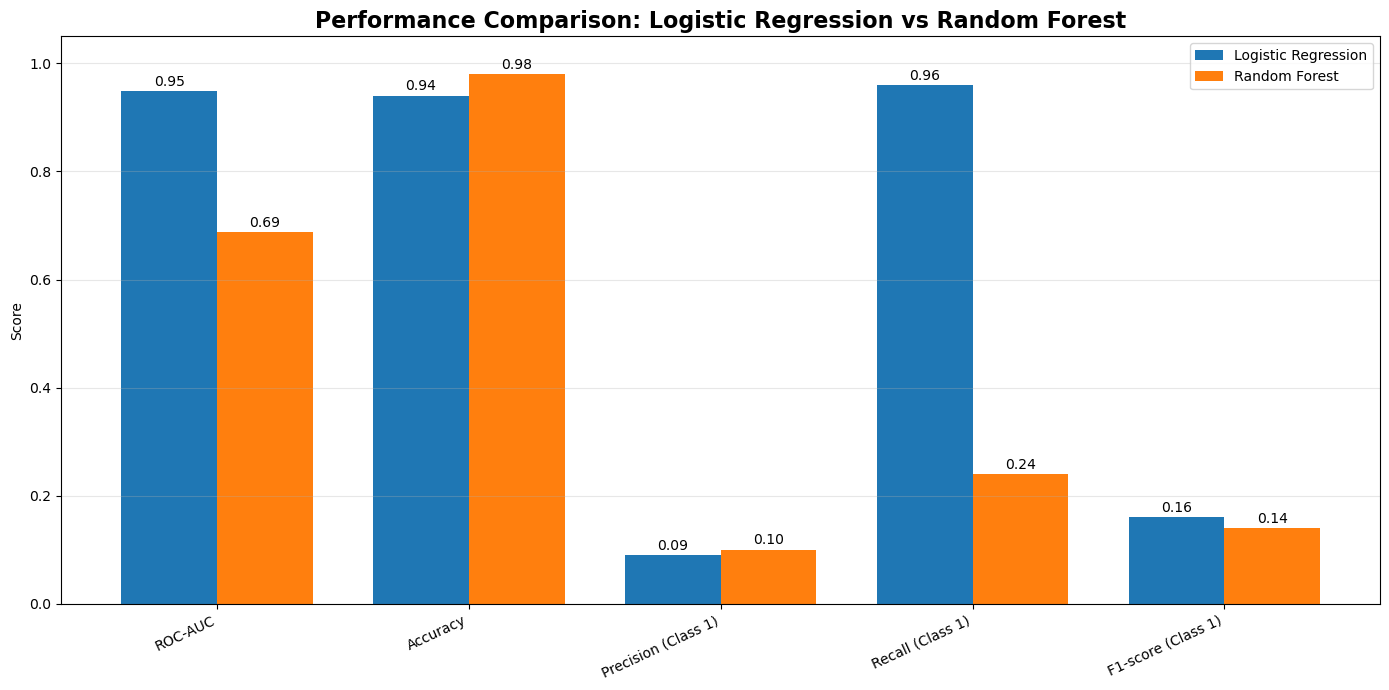

In [249]:
# ---------------------------------------------
# Performance metrics from your results
# ---------------------------------------------
metrics = pd.DataFrame({
    "Metric": ["ROC-AUC", "Accuracy", "Precision (Class 1)", "Recall (Class 1)", "F1-score (Class 1)"],
    "Logistic Regression": [0.9487, 0.94, 0.09, 0.96, 0.16],
    "Random Forest":       [0.6872, 0.98, 0.10, 0.24, 0.14]
})

# ---------------------------------------------
# Side-by-side bar chart
# ---------------------------------------------
x = np.arange(len(metrics["Metric"]))
width = 0.38

plt.figure(figsize=(14,7))

plt.bar(
    x - width/2,
    metrics["Logistic Regression"],
    width,
    label="Logistic Regression"
)

plt.bar(
    x + width/2,
    metrics["Random Forest"],
    width,
    label="Random Forest"
)

# Labels
plt.xticks(x, metrics["Metric"], rotation=25, ha="right")
plt.ylabel("Score")
plt.title("Performance Comparison: Logistic Regression vs Random Forest", fontsize=16, weight="bold")
plt.ylim(0, 1.05)
plt.legend()

# Value labels
for i, val in enumerate(metrics["Logistic Regression"]):
    plt.text(i - width/2, val + 0.01, f"{val:.2f}", ha="center", fontsize=10)

for i, val in enumerate(metrics["Random Forest"]):
    plt.text(i + width/2, val + 0.01, f"{val:.2f}", ha="center", fontsize=10)

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [91]:
# Let's examine the contribution of each factor

In [92]:
# Estimate the coefficients
coeffs = pd.Series(lr.coef_[0], index=X.columns).sort_values()
coeffs

ProductSubcategoryID_9.0    -17.481131
ProductSubcategoryID_10.0    -5.611196
ProductSubcategoryID_5.0     -2.324267
ProductSubcategoryID_11.0    -1.529892
ProductSubcategoryID_17.0    -1.424766
ProductSubcategoryID_8.0     -1.180661
ProductSubcategoryID_4.0     -1.163476
operation_count              -0.116381
distinct_locations           -0.116381
OrderQty                      0.018484
ProductSubcategoryID_3.0      0.049378
ProductSubcategoryID_2.0      0.149405
ProductSubcategoryID_12.0     0.962727
ProductSubcategoryID_14.0     2.456226
dtype: float64

In [93]:
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances.sort_values(ascending=False)

OrderQty                     0.967979
ProductSubcategoryID_9.0     0.008609
ProductSubcategoryID_2.0     0.005450
operation_count              0.003934
distinct_locations           0.002809
ProductSubcategoryID_14.0    0.002500
ProductSubcategoryID_17.0    0.001397
ProductSubcategoryID_11.0    0.001388
ProductSubcategoryID_10.0    0.001317
ProductSubcategoryID_5.0     0.001194
ProductSubcategoryID_3.0     0.001144
ProductSubcategoryID_8.0     0.000973
ProductSubcategoryID_12.0    0.000814
ProductSubcategoryID_4.0     0.000493
dtype: float64

# Now let's build the NL intepretation layer

In [95]:

# Metrics
roc_auc_lr = roc_auc_score(y_test, y_prob_lr)
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

report_lr = classification_report(y_test, y_pred_lr, output_dict=True, zero_division=0)
report_rf = classification_report(y_test, y_pred_rf, output_dict=True, zero_division=0)

cm_lr = confusion_matrix(y_test, y_pred_lr)
cm_rf = confusion_matrix(y_test, y_pred_rf)

# Logistic coefficients
coef_lr = pd.Series(lr.coef_[0], index=X_train.columns).sort_values(ascending=False)

top_positive_lr = coef_lr.head(10).to_dict()
top_negative_lr = coef_lr.tail(10).to_dict()

# Random forest feature importance
feat_rf = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
top_features_rf = feat_rf.head(10).to_dict()

In [96]:
interpretation_user_content = f"""
You are a manufacturing data science analyst.

Interpret the results of a scrap risk classification task for AdventureWorks.

Context:
- Target: scrap_flag (1 = work order incurred scrap, 0 = no scrap)
- Models compared: Logistic Regression and Random Forest
- Features include order quantity, operation count, distinct locations, and one-hot encoded product subcategory fields.

Model performance:
- Logistic Regression ROC-AUC: {roc_auc_lr:.4f}
- Random Forest ROC-AUC: {roc_auc_rf:.4f}

Logistic Regression classification report:
{pd.DataFrame(report_lr).transpose().to_string()}

Random Forest classification report:
{pd.DataFrame(report_rf).transpose().to_string()}

Logistic Regression confusion matrix:
{cm_lr}

Random Forest confusion matrix:
{cm_rf}

Top positive Logistic Regression coefficients:
{top_positive_lr}

Top negative Logistic Regression coefficients:
{top_negative_lr}

Top Random Forest feature importances:
{top_features_rf}

Return valid JSON only using this structure:
{{
  "overall_assessment": "short summary of model performance",
  "best_model": "which model performed better and why",
  "top_drivers": [
    "driver 1",
    "driver 2",
    "driver 3"
  ],
  "shop_floor_recommendations": [
    "recommendation 1",
    "recommendation 2",
    "recommendation 3"
  ],
  "limitations": [
    "limitation 1",
    "limitation 2"
  ]
}}
"""

In [97]:
message4 = [
    {
        "role": "system",
        "content": "You are an expert manufacturing data analyst. Be evidence-based and concise. Return valid JSON only."
    },
    {
        "role": "user",
        "content": interpretation_user_content   # MUST be a string
    }
]
message4

[{'role': 'system',
  'content': 'You are an expert manufacturing data analyst. Be evidence-based and concise. Return valid JSON only.'},
 {'role': 'user',
  'content': '\nYou are a manufacturing data science analyst.\n\nInterpret the results of a scrap risk classification task for AdventureWorks.\n\nContext:\n- Target: scrap_flag (1 = work order incurred scrap, 0 = no scrap)\n- Models compared: Logistic Regression and Random Forest\n- Features include order quantity, operation count, distinct locations, and one-hot encoded product subcategory fields.\n\nModel performance:\n- Logistic Regression ROC-AUC: 0.9487\n- Random Forest ROC-AUC: 0.6872\n\nLogistic Regression classification report:\n              precision    recall  f1-score      support\n0              0.999719  0.940827  0.969379  7571.000000\n1              0.087576  0.955556  0.160448    45.000000\naccuracy       0.940914  0.940914  0.940914     0.940914\nmacro avg      0.543648  0.948191  0.564914  7616.000000\nweighted av

In [98]:
response_interpret = client.chat.completions.create(
    model="gpt-4o-mini",
    messages=message4
)

In [99]:
# Let's parse the response_interpret
import json

raw_interpret = response_interpret.choices[0].message.content.strip()

if raw_interpret.startswith("```json"):
    raw_interpret = raw_interpret.removeprefix("```json").removesuffix("```").strip()
elif raw_interpret.startswith("```"):
    raw_interpret = raw_interpret.removeprefix("```").removesuffix("```").strip()

interpretation_plan = json.loads(raw_interpret)
interpretation_plan

{'overall_assessment': 'The Logistic Regression model outperformed the Random Forest model significantly, highlighting its capability to differentiate between scrap and non-scrap work orders.',
 'best_model': "Logistic Regression performed better due to its higher ROC-AUC score of 0.9487 compared to Random Forest's 0.6872, as well as superior precision and recall for detecting scrap instances.",
 'top_drivers': ['ProductSubcategoryID_14.0',
  'OrderQty',
  'ProductSubcategoryID_9.0'],
 'shop_floor_recommendations': ['Focus on products in subcategory 14 to minimize scrap.',
  'Monitor order quantities to manage scrap risks effectively.',
  'Train staff on processes related to high-scrap subcategories.'],
 'limitations': ['Logistic Regression has limited ability to capture complex interactions compared to Random Forest.',
  'The model may be biased due to imbalanced classes, suggesting further exploration into underrepresented scrap instances.']}

In [100]:
print("Overall assessment:", interpretation_plan["overall_assessment"])
print("Best model:", interpretation_plan["best_model"])

print("\nTop drivers:")
for item in interpretation_plan["top_drivers"]:
    print("-", item)

print("\nShop-floor recommendations:")
for item in interpretation_plan["shop_floor_recommendations"]:
    print("-", item)

print("\nLimitations:")
for item in interpretation_plan["limitations"]:
    print("-", item)

Overall assessment: The Logistic Regression model outperformed the Random Forest model significantly, highlighting its capability to differentiate between scrap and non-scrap work orders.
Best model: Logistic Regression performed better due to its higher ROC-AUC score of 0.9487 compared to Random Forest's 0.6872, as well as superior precision and recall for detecting scrap instances.

Top drivers:
- ProductSubcategoryID_14.0
- OrderQty
- ProductSubcategoryID_9.0

Shop-floor recommendations:
- Focus on products in subcategory 14 to minimize scrap.
- Monitor order quantities to manage scrap risks effectively.
- Train staff on processes related to high-scrap subcategories.

Limitations:
- Logistic Regression has limited ability to capture complex interactions compared to Random Forest.
- The model may be biased due to imbalanced classes, suggesting further exploration into underrepresented scrap instances.


# Question 5

In [102]:
user_question5 = """
Forecast which finished goods will be at risk of stockout given recent transaction history and current on-hand. Approach:
• Build consumption signals from TransactionHistory (sales/work order issues)
• Simple baseline: moving-average demand + reorder-point logic
• ML: classification of “stockout next N days” using lag features
"""

In [103]:
user_content8 = f"""
Database: AdventureWorks
Task: Convert the following natural language request into SQL Server SQL.

Schema summary:
{database_schema}

Business context:
- This database represents a manufacturing company.
- The goal is to support inventory risk analysis for finished goods.

Important table hints:
- Inventory: Production.ProductInventory + Production.Product + Production.Location
- Transactions: Production.TransactionHistory + Production.Product
- Stockout modelling table: Production.ProductInventory + Production.TransactionHistory + Production.Product

Natural language request:
{user_question5}

Output requirements:
- Return valid JSON only.
"""

In [104]:
message5 = [
    {
        "role": "system",
        "content": system
    },
    {
        "role": "user",
        "content": user_content8   # MUST be a string
    }
]
message5

[{'role': 'system',
  'content': 'You are an expert data analyst and SQL generator for the AdventureWorks database.\n\nYour task is to translate a user’s natural language manufacturing or business question into a safe, correct SQL Server query and a brief explanation.\n\nRules:\n1. Only generate read-only SQL.\n2. Allowed query types are:\n   - SELECT\n   - Common Table Expressions (CTEs)\n   - ORDER BY\n   - GROUP BY\n   - HAVING\n   - JOINs\n   - window functions\n   - recursive CTEs if needed\n3. Do not generate:\n   - INSERT\n   - UPDATE\n   - DELETE\n   - DROP\n   - ALTER\n   - TRUNCATE\n   - EXEC\n   - MERGE\n   - stored procedures\n4. The SQL dialect is Microsoft SQL Server (AdventureWorks).\n5. Prefer fully qualified table names, for example:\n   Production.WorkOrder\n   Production.Product\n   Production.ProductInventory\n6. Use TOP for row limits, not LIMIT.\n7. If the question is ambiguous, make the smallest reasonable assumption and state it briefly.\n8. If the question cann

In [105]:
response = client.chat.completions.create(
    model="gpt-4o-mini",
    messages=message5   # ✅ correct
)
print(response.choices[0].message.content)

{
  "question_understanding": "Analyze finished goods inventory risk of stockouts based on transaction history and current inventory levels.",
  "assumptions": ["Only finished goods are considered for forecasting stockouts.", "Moving-average demand can't be calculated directly due to lack of time period specifics."],
  "sql": "WITH RecentTransactions AS ( SELECT ProductID, SUM(Quantity) AS TotalSold FROM Production.TransactionHistory WHERE TransactionDate >= DATEADD(DAY, -30, GETDATE()) GROUP BY ProductID ), CurrentInventory AS ( SELECT p.ProductID, p.Name, pi.Quantity, p.ReorderPoint FROM Production.Product AS p JOIN Production.ProductInventory AS pi ON p.ProductID = pi.ProductID WHERE p.FinishedGoodsFlag = 1 ) SELECT c.ProductID, c.Name, c.Quantity, c.ReorderPoint, r.TotalSold, CASE WHEN c.Quantity <= c.ReorderPoint THEN 'At Risk' ELSE 'Sufficient' END AS StockRisk FROM CurrentInventory AS c LEFT JOIN RecentTransactions AS r ON c.ProductID = r.ProductID;",
  "explanation": "The query

# Outpout Evaluation
## Strength
- A SQL table suitable for implementing the ML part
- Consistent JSON output
## Weakness
- Just like in Part D, the NL-SQL interface has not capacity to implememnt the ML needed
- Add SUN() to **pi.Quantity AS OnHand** because a product can exist in multiple inventory location
- ci.OnHand + rt.TotalSold < ci.ReorderPoint is logically weak. If TotalSold represents demand/consumption, adding it to on-hand inventory makes little business sense; a better simple proxy is to compare on-hand vs recent demand.
- It does not clearly separate a modelling table from a final risk label.

In [107]:
user_content9 = f"""
Database: AdventureWorks
Task: Convert the following natural language request into SQL Server SQL.
Schema summary:
{database_schema}

Example:

Input:
Build a product-level modelling table for inventory risk / stockout prediction.
Return one row per finished good with:
- ProductID
- product name or descriptor
- current total on-hand quantity
- reorder point
- recent demand signal from transaction history
- transaction count
- average transaction quantity
- stockout_risk_flag

Output:
{{
  "question_understanding": "Build a product-level modelling table for predicting which finished goods are at risk of stockout using current inventory and recent transaction history.",
  "assumptions": [
    "Only finished goods are included.",
    "Recent demand is approximated using transactions from the last 30 days.",
    "Current on-hand inventory should be summed across all inventory locations.",
    "A simple stockout-risk proxy is used in this first version rather than a full forecasting model."
  ],
  "sql": "WITH RecentTransactions AS ( SELECT th.ProductID, SUM(th.Quantity) AS TotalRecentDemand, COUNT(*) AS TransactionCount, AVG(CAST(th.Quantity AS float)) AS AvgTransactionQty FROM Production.TransactionHistory AS th WHERE th.TransactionDate >= DATEADD(DAY, -30, GETDATE()) GROUP BY th.ProductID ), CurrentInventory AS ( SELECT p.ProductID, p.Name AS ProductName, SUM(pi.Quantity) AS TotalOnHand, p.ReorderPoint FROM Production.Product AS p JOIN Production.ProductInventory AS pi ON p.ProductID = pi.ProductID WHERE p.FinishedGoodsFlag = 1 GROUP BY p.ProductID, p.Name, p.ReorderPoint ) SELECT ci.ProductID, ci.ProductName, ci.TotalOnHand, ci.ReorderPoint, COALESCE(rt.TotalRecentDemand, 0) AS TotalRecentDemand, COALESCE(rt.TransactionCount, 0) AS TransactionCount, COALESCE(rt.AvgTransactionQty, 0) AS AvgTransactionQty, CASE WHEN ci.TotalOnHand <= ci.ReorderPoint THEN 1 WHEN ci.TotalOnHand < COALESCE(rt.TotalRecentDemand, 0) THEN 1 ELSE 0 END AS stockout_risk_flag FROM CurrentInventory AS ci LEFT JOIN RecentTransactions AS rt ON ci.ProductID = rt.ProductID ORDER BY stockout_risk_flag DESC, ci.ProductName;",
  "explanation": "The query creates a finished-goods inventory risk table by aggregating on-hand stock across all locations and combining it with recent transaction-based demand features from the last 30 days. It then applies a simple stockout-risk rule based on reorder point and recent demand.",
  "result_shape": "One row per finished good containing ProductID, ProductName, TotalOnHand, ReorderPoint, TotalRecentDemand, TransactionCount, AvgTransactionQty, and stockout_risk_flag.",
  "validation_checks": [
    "Verify that inventory is summed across all locations for each product.",
    "Verify that only finished goods are included.",
    "Check that products with no recent transactions still appear with zero-filled demand features.",
    "Check that stockout_risk_flag is 1 only when the rule conditions are met."
  ],
  "plot_suggestion": {{
    "recommended": true,
    "plot_type": "bar",
    "x": "ProductName",
    "y": "TotalOnHand",
    "title": "Finished Goods Inventory and Stockout Risk"
  }}
}}

---

Business context:
- This database represents a manufacturing company.
- The goal is to support inventory risk analysis for finished goods.

Important table hints:
- Inventory: Production.ProductInventory + Production.Product + Production.Location
- Transactions: Production.TransactionHistory + Production.Product
- Stockout modelling table: Production.ProductInventory + Production.TransactionHistory + Production.Product

Natural language request:
{user_question5}

Output requirements:
- Return valid JSON only.
"""

In [108]:
message5 = [
    {
        "role": "system",
        "content": system
    },
    {
        "role": "user",
        "content": user_content9   # MUST be a string
    }
]
message5

[{'role': 'system',
  'content': 'You are an expert data analyst and SQL generator for the AdventureWorks database.\n\nYour task is to translate a user’s natural language manufacturing or business question into a safe, correct SQL Server query and a brief explanation.\n\nRules:\n1. Only generate read-only SQL.\n2. Allowed query types are:\n   - SELECT\n   - Common Table Expressions (CTEs)\n   - ORDER BY\n   - GROUP BY\n   - HAVING\n   - JOINs\n   - window functions\n   - recursive CTEs if needed\n3. Do not generate:\n   - INSERT\n   - UPDATE\n   - DELETE\n   - DROP\n   - ALTER\n   - TRUNCATE\n   - EXEC\n   - MERGE\n   - stored procedures\n4. The SQL dialect is Microsoft SQL Server (AdventureWorks).\n5. Prefer fully qualified table names, for example:\n   Production.WorkOrder\n   Production.Product\n   Production.ProductInventory\n6. Use TOP for row limits, not LIMIT.\n7. If the question is ambiguous, make the smallest reasonable assumption and state it briefly.\n8. If the question cann

In [109]:
response = client.chat.completions.create(
    model="gpt-4o-mini",
    messages=message5   # ✅ correct
)
print(response.choices[0].message.content)

{
  "question_understanding": "Forecast which finished goods will be at risk of stockout using recent transaction history and current on-hand inventory.",
  "assumptions": [
    "Only finished goods are included in the analysis.",
    "Recent demand is approximated using transactions from the last 30 days.",
    "Current on-hand inventory should be summed across all inventory locations.",
    "A moving average over the past 30 days is used to estimate average demand."
  ],
  "sql": "WITH RecentDemand AS ( SELECT th.ProductID, AVG(th.Quantity) AS MovingAvgDemand FROM Production.TransactionHistory AS th WHERE th.TransactionDate >= DATEADD(DAY, -30, GETDATE()) GROUP BY th.ProductID ), CurrentInventory AS ( SELECT p.ProductID, p.Name AS ProductName, SUM(pi.Quantity) AS TotalOnHand, p.ReorderPoint FROM Production.Product AS p JOIN Production.ProductInventory AS pi ON p.ProductID = pi.ProductID WHERE p.FinishedGoodsFlag = 1 GROUP BY p.ProductID, p.Name, p.ReorderPoint ) SELECT ci.ProductID, 

In [110]:
query5 = """
WITH RecentDemand AS (
    SELECT
        th.ProductID,
        AVG(th.Quantity) AS MovingAverageDemand
    FROM Production.TransactionHistory AS th
    WHERE th.TransactionDate >= DATEADD(DAY, -30, GETDATE())
    GROUP BY th.ProductID
),
InventoryLevels AS (
    SELECT
        p.ProductID,
        p.Name AS ProductName,
        SUM(pi.Quantity) AS TotalOnHand,
        p.ReorderPoint
    FROM Production.Product AS p
    JOIN Production.ProductInventory AS pi
        ON p.ProductID = pi.ProductID
    WHERE p.FinishedGoodsFlag = 1
    GROUP BY
        p.ProductID,
        p.Name,
        p.ReorderPoint
)
SELECT
    il.ProductID,
    il.ProductName,
    il.TotalOnHand,
    il.ReorderPoint,
    COALESCE(rd.MovingAverageDemand, 0) AS MovingAverageDemand,
    CASE
        WHEN il.TotalOnHand <= il.ReorderPoint THEN 1
        WHEN il.TotalOnHand < COALESCE(rd.MovingAverageDemand, 0) THEN 1
        ELSE 0
    END AS stockout_risk_flag
FROM InventoryLevels AS il
LEFT JOIN RecentDemand AS rd
    ON il.ProductID = rd.ProductID
ORDER BY
    stockout_risk_flag DESC;
"""

df_stockout = pd.read_sql(query5, conn)
df_stockout

C:\Users\emper\AppData\Local\Temp\ipykernel_55500\86143689.py:43: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_stockout = pd.read_sql(query5, conn)


,ProductID,ProductName,TotalOnHand,ReorderPoint,MovingAverageDemand,stockout_risk_flag
0,910,HL Mountain Seat/Saddle,355,375,0,1
1,956,"Touring-1000 Yellow, 54",75,75,0,1
2,859,"Half-Finger Gloves, M",0,3,0,1
3,853,"Women's Tights, M",0,3,0,1
4,876,Hitch Rack - 4-Bike,0,3,0,1
...,...,...,...,...,...,...
218,848,Headlights - Weatherproof,216,3,0,0
219,849,"Men's Sports Shorts, M",108,3,0,0
220,850,"Men's Sports Shorts, L",144,3,0,0
221,851,"Men's Sports Shorts, XL",180,3,0,0


In [111]:
#df_stockout.to_csv("Stockout_df.csv", index=False)

In [164]:
stockout = pd.read_csv("Stockout_df.csv")
stockout

,ProductID,ProductName,TotalOnHand,ReorderPoint,MovingAverageDemand,stockout_risk_flag
0,910,HL Mountain Seat/Saddle,355,375,0,1
1,956,"Touring-1000 Yellow, 54",75,75,0,1
2,859,"Half-Finger Gloves, M",0,3,0,1
3,853,"Women's Tights, M",0,3,0,1
4,876,Hitch Rack - 4-Bike,0,3,0,1
...,...,...,...,...,...,...
218,848,Headlights - Weatherproof,216,3,0,0
219,849,"Men's Sports Shorts, M",108,3,0,0
220,850,"Men's Sports Shorts, L",144,3,0,0
221,851,"Men's Sports Shorts, XL",180,3,0,0


In [212]:
stockout.stockout_risk_flag.value_counts()

stockout_risk_flag
0    217
1      6
Name: count, dtype: int64